# Bidding Predictions for Construction — Lab 4 v1.9

**Course:** Machine Learning &nbsp;|&nbsp; **Competition:** Kaggle — Bidding Predictions for Construction  
**Version:** v1.9 &nbsp;|&nbsp; **Metric:** RMSLE (Root Mean Squared Log Error)

### v1.9 Major Changes
| Change | Why |
|---|---|
| **Blended reconstruction baseline** (`log_recon_blend`) | Reduce dependence on single reconstruction variant |
| **Full-year training with recency sample weights** | Keep data coverage while emphasizing 2024/2023 patterns |
| **Ratio outlier stabilization** (winsorized + log-deviation features) | Control heavy-tail noise seen in recency ratios |
| **Dual-score model selection** (GroupKFold + temporal holdout) | Reduce local-public mismatch risk |
| **RobustBlend meta-selection** | Combine boosters with objective aligned to stability and drift |


## 1. Imports and Setup

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import OrdinalEncoder, RobustScaler
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb
from lightgbm import LGBMRegressor
import lightgbm as lgb_mod

try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False
    print("WARNING: CatBoost not installed. Run: pip install catboost")

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False
    print("INFO: Optuna not installed. Run: pip install optuna  (optional)")

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)
print(f"Setup complete.  CatBoost={CATBOOST_AVAILABLE}  Optuna={OPTUNA_AVAILABLE}")

Setup complete.  CatBoost=True  Optuna=True


## 2. Load and Explore the Dataset

Two-level structure:
- **Pay-item level** (`raw_train`, `raw_test`): one row per line item per bid. Has `amount` (unit price) column in train only.
- **Job level** (`train_summary`, `test`): one row per contractor-job pair. Target is `total_bid`.

In [32]:
raw_train     = pd.read_csv("data/raw_train.csv")
train_summary = pd.read_csv("data/train_summary.csv")
raw_test      = pd.read_csv("data/raw_test.csv")
test          = pd.read_csv("data/test.csv")
sample_sub    = pd.read_csv("data/sample_submission.csv")

print(f"raw_train:     {raw_train.shape}")
print(f"train_summary: {train_summary.shape}")
print(f"raw_test:      {raw_test.shape}")
print(f"test:          {test.shape}")
print(f"sample_sub:    {sample_sub.shape}")

raw_train:     (832056, 15)
train_summary: (10620, 6)
raw_test:      (120305, 13)
test:          (1447, 6)
sample_sub:    (1447, 2)


### 2.1 Data Overview

In [33]:
print("=== raw_train ===")
print(raw_train.dtypes)
print()
raw_train.head(3)

=== raw_train ===
quantity                    float64
amount                      float64
job_category_description     object
bid_date                     object
total_bid                   float64
num_pay_items                 int64
pay_item_description         object
unit_english_id              object
category_id                   int64
category_description         object
job_id                       object
contractor_id                object
primary_location             object
pay_item_id                  object
row_id                       object
dtype: object



,quantity,amount,job_category_description,bid_date,total_bid,num_pay_items,pay_item_description,unit_english_id,category_id,category_description,job_id,contractor_id,primary_location,pay_item_id,row_id
0,1.0,7000.0,BRIDGE,2018-01-18,453231.70,55,CONSTRUCTION ENGINEERING,EACH,25,MOBILIZATION,JOB_002829,CON_000015,LOC_000091,ITEM_003580,JOB_002829__CON_000015
1,1.0,11000.0,BRIDGE,2018-01-18,148876.00,20,CONSTRUCTION ENGINEERING,EACH,25,MOBILIZATION,JOB_001298,CON_000015,LOC_000028,ITEM_003580,JOB_001298__CON_000015
2,1.0,24000.0,BRIDGE,2018-01-18,1513003.05,101,CONSTRUCTION ENGINEERING,EACH,25,MOBILIZATION,JOB_001294,CON_000015,LOC_000028,ITEM_003580,JOB_001294__CON_000015


In [34]:
print("=== train_summary ===")
print(train_summary.dtypes)
print()
train_summary.head(3)

=== train_summary ===
job_id                       object
contractor_id                object
total_bid                   float64
bid_date                     object
primary_location             object
job_category_description     object
dtype: object



,job_id,contractor_id,total_bid,bid_date,primary_location,job_category_description
0,JOB_000001,CON_000047,213693.50,2020-01-15,LOC_000078,EROSION CONTROL
1,JOB_000001,CON_000091,219935.95,2020-01-15,LOC_000078,EROSION CONTROL
2,JOB_000001,CON_000137,188000.00,2020-01-15,LOC_000078,EROSION CONTROL


In [35]:
print("=== Missing Values ===")
print("raw_train nulls:")
print(raw_train.isna().sum()[raw_train.isna().sum() > 0])
print()
print("train_summary nulls:")
print(train_summary.isna().sum()[train_summary.isna().sum() > 0])

=== Missing Values ===
raw_train nulls:
unit_english_id    2
dtype: int64

train_summary nulls:
Series([], dtype: int64)


In [36]:
print("=== Dataset Scale ===")
print(f"Unique jobs in raw_train:     {raw_train['job_id'].nunique()}")
print(f"Unique contractors in train:  {raw_train['contractor_id'].nunique()}")
print(f"Unique jobs in test:          {raw_test['job_id'].nunique()}")
print(f"Unique contractors in test:   {raw_test['contractor_id'].nunique()}")
test_ctrs  = set(raw_test['contractor_id'].unique())
train_ctrs = set(raw_train['contractor_id'].unique())
print(f"Test contractors seen in train: {len(test_ctrs & train_ctrs)}/{len(test_ctrs)}")
print(f"Unseen test contractors:        {len(test_ctrs - train_ctrs)}")

=== Dataset Scale ===
Unique jobs in raw_train:     3350
Unique contractors in train:  228
Unique jobs in test:          364
Unique contractors in test:   117
Test contractors seen in train: 108/117
Unseen test contractors:        9


### 2.2 Key Structural Facts

**Critical structural properties of the data:**

1. **`raw_test` has no `amount` column** — unit prices are sealed. All features must come from quantities and categorical information available in both files.
2. **All test bids are from 2025; all training bids are 2018–2024.** This temporal gap is the single most important structural problem and drives v1.5's residual modeling approach.
3. **On most jobs, all competing contractors bid identical quantities** — 363 of 364 test jobs have identical `qty_sum` across contractors. Quantity features distinguish jobs from each other but not contractors within the same job.
4. **364 unique test jobs, avg ~4 competitors per job** (range 1–11).
5. **117 test contractors, 108 in training, 9 unseen.**

## 3. Data Cleaning

### 3.1 Fix Types and Missing Values

In [37]:
for df in [raw_train, train_summary, raw_test, test]:
    df['bid_date'] = pd.to_datetime(df['bid_date'])

raw_train['quantity'] = pd.to_numeric(raw_train['quantity'], errors='coerce').fillna(0)
raw_test['quantity']  = pd.to_numeric(raw_test['quantity'],  errors='coerce').fillna(0)
raw_train['amount']   = pd.to_numeric(raw_train['amount'],   errors='coerce')
raw_train['bid_year_raw'] = raw_train['bid_date'].dt.year

print("Date range — train:", raw_train['bid_date'].min().date(), "→", raw_train['bid_date'].max().date())
print("Date range — test: ", raw_test['bid_date'].min().date(), "→", raw_test['bid_date'].max().date())
print()
print("Train year distribution:")
print(raw_train.groupby('bid_year_raw')['job_id'].nunique().rename('n_jobs'))
print()
print(f"Amount nulls in raw_train: {raw_train['amount'].isna().sum()}")
raw_train = raw_train.dropna(subset=['amount'])
raw_train = raw_train[raw_train['amount'] > 0].copy()
print(f"raw_train after cleaning: {raw_train.shape}")

Date range — train: 2018-01-18 → 2024-12-11
Date range — test:  2025-01-15 → 2025-12-10

Train year distribution:
bid_year_raw
2018    467
2019    534
2020    544
2021    441
2022    479
2023    458
2024    427
Name: n_jobs, dtype: int64

Amount nulls in raw_train: 0
raw_train after cleaning: (832056, 16)


**Insight:** The temporal gap is the most important structural finding in cleaning. Training spans 2018–2024 and test is entirely 2025. This 1–7 year gap means construction costs have inflated substantially. v1.5 addresses this with three complementary approaches: (1) exponentially weighted reconstruction that emphasises recent prices, (2) residual modeling that decouples the price-level signal from the contractor-deviation signal, and (3) a 2022+ training filter that discards the most stale pricing patterns.

## 4. Feature Engineering

**Strategy — v1.5 Three-tier architecture:**
1. *Job-level scale*: Multiple reconstructions from historical prices (all-history, recent 2023–2024, exponentially weighted) — the dominant signal
2. *Contractor-level deviation*: Within-job positioning, contractor profile size, structural diversity — learned as a residual
3. *Context*: Job category, location, temporal features — encoded as target-encoded categoricals

**Key v1.5 change:** We now train the model to predict the *residual* `log1p(total_bid) - log_recon_recent` rather than the raw log-bid. This separates the job-scale problem (handled by reconstruction) from the contractor-deviation problem (handled by the model), dramatically reducing era overfitting.

### 4.1 Historical Price Statistics

We compute item-level price statistics in three windows:
- **All years** (2018–2024): Maximum data volume for coverage; used as fallback.
- **Recent** (2023–2024): Closest to 2025 test conditions; highest inflation accuracy.
- **Exponentially weighted** (2018–2024, decay by year): Smooth interpolation between all-history and recent — avoids the hard binary cutoff of the recent filter.

In [38]:
# All-history item prices
item_price_all = (
    raw_train.groupby('pay_item_id')['amount']
    .agg(item_price_median='median', item_price_mean='mean')
    .reset_index()
)

# Recent-only item prices (2023–2024, closest to test year 2025)
recent_mask = raw_train['bid_year_raw'] >= 2023
item_price_recent = (
    raw_train[recent_mask].groupby('pay_item_id')['amount']
    .agg(item_price_recent_median='median', item_price_recent_mean='mean')
    .reset_index()
)

# Exponentially weighted: 2024→4×, 2023→2×, 2022→1×, 2021→0.5×, 2020→0.25×, ...
year_weights_map = {2024: 4.0, 2023: 2.0, 2022: 1.0, 2021: 0.5, 2020: 0.25, 2019: 0.125, 2018: 0.0625}
raw_train_ew = raw_train.copy()
raw_train_ew['_w'] = raw_train_ew['bid_year_raw'].map(year_weights_map).fillna(0.03125)
raw_train_ew['_wamt'] = raw_train_ew['amount'] * raw_train_ew['_w']

ew_stats = (
    raw_train_ew.groupby('pay_item_id')
    .agg(_wamt_sum=('_wamt', 'sum'), _w_sum=('_w', 'sum'))
    .reset_index()
)
ew_stats['item_price_ew_mean'] = ew_stats['_wamt_sum'] / ew_stats['_w_sum'].clip(lower=1e-8)
item_price_ew = ew_stats[['pay_item_id', 'item_price_ew_mean']].copy()

# Contractor-specific item prices (their own historical rates)
contractor_item_prices = (
    raw_train.groupby(['contractor_id', 'pay_item_id'])['amount']
    .median().reset_index()
    .rename(columns={'amount': 'ctr_item_price'})
)

# Recent contractor prices (2022-2024)
recent_mask2 = raw_train['bid_year_raw'] >= 2022
ctr_item_recent = (
    raw_train[recent_mask2].groupby(['contractor_id', 'pay_item_id'])['amount']
    .median().reset_index()
    .rename(columns={'amount': 'ctr_item_price_recent'})
)

global_price   = float(raw_train['amount'].median())
global_recent  = float(raw_train[recent_mask]['amount'].median())
# Use median of per-item weighted means as fallback — much more robust than
# the global weighted arithmetic mean, which gets dominated by expensive outliers.
global_ew      = float(item_price_ew['item_price_ew_mean'].median())

# Coverage check
test_items   = set(raw_test['pay_item_id'].unique())
train_items  = set(item_price_all['pay_item_id'].unique())
recent_items = set(item_price_recent['pay_item_id'].unique())
print(f"Test items with ALL-history price:    {len(test_items & train_items)}/{len(test_items)} ({len(test_items & train_items)/len(test_items)*100:.0f}%)")
print(f"Test items with RECENT price:         {len(test_items & recent_items)}/{len(test_items)} ({len(test_items & recent_items)/len(test_items)*100:.0f}%)")
print(f"Global fallback (all):    ${global_price:,.2f}")
print(f"Global fallback (recent): ${global_recent:,.2f}")
print(f"Global fallback (ew):     ${global_ew:,.2f}")

Test items with ALL-history price:    1965/2070 (95%)
Test items with RECENT price:         1761/2070 (85%)
Global fallback (all):    $80.00
Global fallback (recent): $100.00
Global fallback (ew):     $649.18


### 4.2 Reconstruct Total Bid from Historical Prices

**Three reconstructions** — each captures a different regime of cost estimation:
- `recon_all`: Broadest signal, maximum item coverage, slightly stale prices
- `recon_recent`: Closest to 2025 prices, used as the **residual baseline** in v1.5
- `recon_weighted`: Smooth exponential decay — best of both coverage and recency

In [39]:
def build_recon(raw_df, item_stats, price_col, global_p, output_col):
    df = raw_df[['job_id','contractor_id','pay_item_id','quantity']].copy()
    df = df.merge(item_stats[['pay_item_id', price_col]], on='pay_item_id', how='left')
    df[price_col] = df[price_col].fillna(global_p)
    df['line']    = df['quantity'].clip(lower=0) * df[price_col]
    return (df.groupby(['job_id','contractor_id'])['line']
              .sum().reset_index()
              .rename(columns={'line': output_col}))


def build_ctr_recon(raw_df, ctr_prices, price_col, item_fallback, price_fallback_col, global_p, output_col):
    df = raw_df[['job_id','contractor_id','pay_item_id','quantity']].copy()
    df = df.merge(ctr_prices[['contractor_id','pay_item_id',price_col]],
                  on=['contractor_id','pay_item_id'], how='left')
    df = df.merge(item_fallback[['pay_item_id', price_fallback_col]], on='pay_item_id', how='left')
    df['price'] = df[price_col].fillna(df[price_fallback_col]).fillna(global_p)
    df['line']  = df['quantity'].clip(lower=0) * df['price']
    return (df.groupby(['job_id','contractor_id'])['line']
              .sum().reset_index()
              .rename(columns={'line': output_col}))


# Global reconstructions
recon_all_tr  = build_recon(raw_train, item_price_all,    'item_price_median',        global_price,   'recon_all')
recon_all_te  = build_recon(raw_test,  item_price_all,    'item_price_median',        global_price,   'recon_all')

recon_rec_tr  = build_recon(raw_train, item_price_recent, 'item_price_recent_median', global_recent,  'recon_recent')
recon_rec_te  = build_recon(raw_test,  item_price_recent, 'item_price_recent_median', global_recent,  'recon_recent')

recon_ew_tr   = build_recon(raw_train, item_price_ew,     'item_price_ew_mean',       global_ew,      'recon_weighted')
recon_ew_te   = build_recon(raw_test,  item_price_ew,     'item_price_ew_mean',       global_ew,      'recon_weighted')

# Contractor-specific reconstructions
ctr_recon_tr  = build_ctr_recon(raw_train, contractor_item_prices, 'ctr_item_price',
                                 item_price_all, 'item_price_median', global_price, 'ctr_recon_all')
ctr_recon_te  = build_ctr_recon(raw_test,  contractor_item_prices, 'ctr_item_price',
                                 item_price_all, 'item_price_median', global_price, 'ctr_recon_all')

ctr_recon_rec_tr = build_ctr_recon(raw_train, ctr_item_recent, 'ctr_item_price_recent',
                                    item_price_recent, 'item_price_recent_median', global_recent, 'ctr_recon_recent')
ctr_recon_rec_te = build_ctr_recon(raw_test,  ctr_item_recent, 'ctr_item_price_recent',
                                    item_price_recent, 'item_price_recent_median', global_recent, 'ctr_recon_recent')

# Accuracy check on training
check  = recon_all_tr.merge(raw_train.groupby(['job_id','contractor_id'])['total_bid'].first().reset_index(),
                             on=['job_id','contractor_id'])
ratio  = check['recon_all'] / check['total_bid'].clip(lower=1)
check2 = recon_rec_tr.merge(check[['job_id','contractor_id','total_bid']], on=['job_id','contractor_id'])
ratio2 = check2['recon_recent'] / check2['total_bid'].clip(lower=1)
check3 = recon_ew_tr.merge(check[['job_id','contractor_id','total_bid']], on=['job_id','contractor_id'])
ratio3 = check3['recon_weighted'] / check3['total_bid'].clip(lower=1)

print(f"All-history reconstruction:  Median ratio {ratio.median():.3f}  |  Within ±20%: {((ratio-1).abs()<0.2).mean()*100:.1f}%")
print(f"Recent reconstruction:       Median ratio {ratio2.median():.3f}  |  Within ±20%: {((ratio2-1).abs()<0.2).mean()*100:.1f}%")
print(f"Weighted reconstruction:     Median ratio {ratio3.median():.3f}  |  Within ±20%: {((ratio3-1).abs()<0.2).mean()*100:.1f}%")

All-history reconstruction:  Median ratio 1.082  |  Within ±20%: 42.1%
Recent reconstruction:       Median ratio 1.345  |  Within ±20%: 31.2%
Weighted reconstruction:     Median ratio 1.978  |  Within ±20%: 7.6%


### 4.3 Structural Aggregates from Pay-Item Level

In [40]:
def aggregate_raw(df):
    qty = df.groupby(['job_id','contractor_id'])['quantity'].agg(
        qty_sum='sum', qty_mean='mean', qty_std='std', qty_max='max'
    ).reset_index()
    qty['qty_log_sum'] = np.log1p(qty['qty_sum'].clip(lower=0))

    div = df.groupby(['job_id','contractor_id']).agg(
        num_pay_items_actual   = ('pay_item_id',          'count'),
        num_unique_pay_items   = ('pay_item_id',          'nunique'),
        num_unique_units       = ('unit_english_id',      'nunique'),
        num_unique_categories  = ('category_description', 'nunique'),
    ).reset_index()

    npi = (df.groupby(['job_id','contractor_id'])['num_pay_items']
             .first().reset_index()
             .rename(columns={'num_pay_items':'num_pay_items_stated'}))

    return qty.merge(div, on=['job_id','contractor_id']).merge(npi, on=['job_id','contractor_id'])


job_feats_tr = aggregate_raw(raw_train)
job_feats_te = aggregate_raw(raw_test)
print(f"Structural features — train: {job_feats_tr.shape}  test: {job_feats_te.shape}")

Structural features — train: (10620, 12)  test: (1447, 12)


### 4.4 Contractor Profile and Behavioral Features

**Two layers of contractor signal:**
1. **Structural profile** (from `raw_train`): footprint size, breadth of work — no target info
2. **Behavioral profile** (from `train_summary`): *how* this contractor prices relative to competitors

The behavioral features are the key v1.6 addition. A contractor's tendency to underbid or overbid market
is a durable pattern — it reflects their business model, overhead structure, and competitive strategy.
These patterns are stable across years (contractors don't radically change their pricing model),
making them safe for the 2024→2025 gap.

`ctr_bid_ratio_mean < 1.0` = consistently aggressive (bids below market median)  
`ctr_win_rate` = historical fraction of jobs where they submitted the lowest bid

In [41]:
# ── Structural profile from raw_train (no target info) ─────────────────────
ctr_profile = (
    raw_train.groupby('contractor_id').agg(
        ctr_total_jobs        = ('job_id',              'nunique'),
        ctr_avg_items_per_job = ('num_pay_items',       'mean'),
        ctr_unique_units      = ('unit_english_id',     'nunique'),
        ctr_unique_categories = ('category_description','nunique'),
    ).reset_index()
)

# ── Behavioral profile from train_summary (uses total_bid) ──────────────────
# Uses bid_date for year filtering — already converted to datetime in cleaning.
ts = train_summary[['job_id', 'contractor_id', 'total_bid', 'bid_date']].copy()
ts['_year'] = ts['bid_date'].dt.year

# Job-level stats: median bid and minimum bid (winner) per job
job_agg = ts.groupby('job_id')['total_bid'].agg(
    _job_median='median', _job_min='min'
).reset_index()
ts = ts.merge(job_agg, on='job_id')
ts['_bid_ratio'] = ts['total_bid'] / ts['_job_median'].clip(lower=1)
ts['_is_winner'] = (ts['total_bid'] == ts['_job_min']).astype(float)

# Aggregate per contractor (all training years 2018-2024)
ctr_behavior = ts.groupby('contractor_id').agg(
    ctr_win_rate          = ('_is_winner',  'mean'),
    ctr_bid_ratio_mean    = ('_bid_ratio',  'mean'),
    ctr_bid_ratio_median  = ('_bid_ratio',  'median'),
    ctr_bid_ratio_std     = ('_bid_ratio',  'std'),
).reset_index()

# Recent activity proxy (2022-2024 subset)
ts_rec = ts[ts['_year'] >= 2022]
ctr_rec = ts_rec.groupby('contractor_id').agg(
    ctr_jobs_recent     = ('job_id',     'nunique'),
    ctr_win_rate_recent = ('_is_winner', 'mean'),
).reset_index()

ctr_behavior = ctr_behavior.merge(ctr_rec, on='contractor_id', how='left')
ctr_behavior['ctr_jobs_recent']    = ctr_behavior['ctr_jobs_recent'].fillna(0)
ctr_behavior['ctr_win_rate_recent'] = ctr_behavior['ctr_win_rate_recent'].fillna(
    ctr_behavior['ctr_win_rate'])
# Fraction of career jobs that are recent (2022+) — proxy for current market activity
ctr_behavior = ctr_behavior.merge(
    ctr_profile[['contractor_id','ctr_total_jobs']], on='contractor_id', how='left')
ctr_behavior['ctr_recent_pct'] = (
    ctr_behavior['ctr_jobs_recent'] / ctr_behavior['ctr_total_jobs'].clip(lower=1))
ctr_behavior = ctr_behavior.drop(columns=['ctr_total_jobs'])

print(f"Structural profile:  {ctr_profile.shape}")
print(f"Behavioral profile:  {ctr_behavior.shape}")
print()
print("Behavioral feature distribution:")
print(ctr_behavior[['ctr_win_rate','ctr_bid_ratio_mean','ctr_bid_ratio_median',
                     'ctr_bid_ratio_std','ctr_recent_pct']].describe().round(3))

Structural profile:  (228, 5)
Behavioral profile:  (228, 8)

Behavioral feature distribution:
       ctr_win_rate  ctr_bid_ratio_mean  ctr_bid_ratio_median  \
count       228.000             228.000               228.000   
mean          0.283               1.061                 1.045   
std           0.282               0.280                 0.261   
min           0.000               0.741                 0.677   
25%           0.000               0.969                 0.977   
50%           0.240               1.008                 1.000   
75%           0.418               1.051                 1.023   
max           1.000               3.912                 3.912   

       ctr_bid_ratio_std  ctr_recent_pct  
count            180.000         228.000  
mean               0.167           0.348  
std                0.168           0.343  
min                0.000           0.000  
25%                0.092           0.000  
50%                0.127           0.296  
75%                

### 4.5 Temporal Features

In [42]:
def add_temporal(df):
    df = df.copy()
    df['bid_year']    = df['bid_date'].dt.year
    df['bid_month']   = df['bid_date'].dt.month
    df['bid_quarter'] = df['bid_date'].dt.quarter
    dow = df['bid_date'].dt.dayofweek
    df['bid_dow_sin'] = np.sin(2 * np.pi * dow / 7)
    df['bid_dow_cos'] = np.cos(2 * np.pi * dow / 7)
    return df

train_summary = add_temporal(train_summary)
test          = add_temporal(test)
print("Temporal features added.")

Temporal features added.


### 4.6 Categorical Encoding

In [43]:
for df in [train_summary, test]:
    df['primary_location_orig']   = df['primary_location']
    df['job_category_orig']       = df['job_category_description']

cat_cols = ['primary_location', 'job_category_description']
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
enc.fit(pd.concat([train_summary[cat_cols], test[cat_cols]], ignore_index=True).astype(str))
train_summary[cat_cols] = enc.transform(train_summary[cat_cols].astype(str))
test[cat_cols]          = enc.transform(test[cat_cols].astype(str))
print("Ordinal encoding complete.")

Ordinal encoding complete.


### 4.7 Merge All Features

In [44]:
train_summary['row_id'] = train_summary['job_id'] + '__' + train_summary['contractor_id']

df_train = train_summary.merge(job_feats_tr,   on=['job_id','contractor_id'], how='left')
df_test  = test.merge(         job_feats_te,   on=['job_id','contractor_id'], how='left')

# Structural profile
df_train = df_train.merge(ctr_profile,    on='contractor_id', how='left')
df_test  = df_test.merge( ctr_profile,   on='contractor_id', how='left')

# Behavioral profile (NEW in v1.6 — 9 unseen test contractors get median fill below)
df_train = df_train.merge(ctr_behavior,   on='contractor_id', how='left')
df_test  = df_test.merge( ctr_behavior,   on='contractor_id', how='left')

# Reconstruction features
df_train = df_train.merge(recon_all_tr,        on=['job_id','contractor_id'], how='left')
df_test  = df_test.merge( recon_all_te,        on=['job_id','contractor_id'], how='left')
df_train = df_train.merge(recon_rec_tr,        on=['job_id','contractor_id'], how='left')
df_test  = df_test.merge( recon_rec_te,        on=['job_id','contractor_id'], how='left')
df_train = df_train.merge(recon_ew_tr,         on=['job_id','contractor_id'], how='left')
df_test  = df_test.merge( recon_ew_te,         on=['job_id','contractor_id'], how='left')
df_train = df_train.merge(ctr_recon_tr,        on=['job_id','contractor_id'], how='left')
df_test  = df_test.merge( ctr_recon_te,        on=['job_id','contractor_id'], how='left')
df_train = df_train.merge(ctr_recon_rec_tr,    on=['job_id','contractor_id'], how='left')
df_test  = df_test.merge( ctr_recon_rec_te,    on=['job_id','contractor_id'], how='left')

print(f"df_train: {df_train.shape}  |  df_test: {df_test.shape}")

# Log-transform reconstruction features
for df in [df_train, df_test]:
    df['log_recon_all']        = np.log1p(df['recon_all'].clip(lower=0))
    df['log_recon_recent']     = np.log1p(df['recon_recent'].clip(lower=0))
    df['log_recon_weighted']   = np.log1p(df['recon_weighted'].clip(lower=0))
    df['log_ctr_recon_all']    = np.log1p(df['ctr_recon_all'].clip(lower=0))
    df['log_ctr_recon_recent'] = np.log1p(df['ctr_recon_recent'].clip(lower=0))

    df['recon_recency_ratio']     = df['recon_recent'].clip(lower=1) / df['recon_all'].clip(lower=1)
    df['ctr_recon_recency_ratio'] = df['ctr_recon_recent'].clip(lower=1) / df['ctr_recon_all'].clip(lower=1)
    df['recon_ew_ratio']          = df['recon_weighted'].clip(lower=1) / df['recon_all'].clip(lower=1)

    job_ctr_median           = df.groupby('job_id')['ctr_recon_all'].transform('median')
    job_ctr_std              = df.groupby('job_id')['ctr_recon_all'].transform('std').fillna(1.0)
    df['ctr_vs_job_ratio']   = df['ctr_recon_all'] / job_ctr_median.clip(lower=1)
    df['ctr_vs_job_zscore']  = (df['ctr_recon_all'] - job_ctr_median) / (job_ctr_std + 1.0)
    df['ctr_rank_in_job']    = df.groupby('job_id')['ctr_recon_all'].rank(method='average', pct=True)
    df['job_competitor_count'] = df.groupby('job_id')['contractor_id'].transform('count')

# Fill all nulls with training medians
# (handles 9 unseen test contractors + ctr_bid_ratio_std NaN for single-job contractors)
for col in [c for c in df_train.columns if pd.api.types.is_numeric_dtype(df_train[c])]:
    med = df_train[col].median()
    df_train[col] = df_train[col].fillna(med)
    if col in df_test.columns:
        df_test[col] = df_test[col].fillna(med)

print(f"Nulls — train: {df_train.isnull().sum().sum()}  test: {df_test.isnull().sum().sum()}")

df_train: (10620, 40)  |  df_test: (1447, 39)
Nulls — train: 0  test: 0


### 4.8 K-Fold Target Encoding for Job Category and Location

Target encoding replaces categorical values with a smoothed mean of the log-target, computed using group k-fold to prevent within-fold leakage. The smoothing parameter `alpha=10` shrinks rare categories toward the global mean.

In [45]:
def kfold_te(df, col, log_target, n_splits=5, alpha=10):
    """Group k-fold target encoding — leakage-free for validation."""
    global_mean = float(log_target.mean())
    encoded     = pd.Series(np.full(len(df), global_mean), index=df.index, dtype=float)
    gkf         = GroupKFold(n_splits=n_splits)

    for tr_idx, va_idx in gkf.split(df, groups=df['job_id']):
        fold_cats   = df.iloc[tr_idx][col]
        fold_target = log_target.iloc[tr_idx]
        stats       = fold_target.groupby(fold_cats).agg(['sum','count'])
        stats['sm'] = (stats['sum'] + global_mean * alpha) / (stats['count'] + alpha)
        encoded.iloc[va_idx] = df.iloc[va_idx][col].map(stats['sm']).fillna(global_mean).values
    return encoded


def full_te(df_tr, col, log_target, df_te, alpha=10):
    """Full-training encoding to apply to test set (no leakage concern here)."""
    global_mean = float(log_target.mean())
    stats       = log_target.groupby(df_tr[col]).agg(['sum','count'])
    stats['sm'] = (stats['sum'] + global_mean * alpha) / (stats['count'] + alpha)
    return df_te[col].map(stats['sm']).fillna(global_mean)


log_y = np.log1p(df_train['total_bid'])

for col, te_col in [('job_category_orig', 'job_cat_te'),
                    ('primary_location_orig', 'location_te')]:
    df_train[te_col] = kfold_te(df_train, col, log_y)
    df_test[te_col]  = full_te(df_train, col, log_y, df_test)

print("K-fold target encoding complete.")
print()
for col in ['job_cat_te', 'location_te']:
    corr = np.corrcoef(df_train[col], log_y)[0,1]
    print(f"{col:15s} → correlation with log(total_bid): {corr:.4f}")
print("(~0.5–0.8 expected; would be >0.99 if leaky)")

K-fold target encoding complete.

job_cat_te      → correlation with log(total_bid): 0.4628
location_te     → correlation with log(total_bid): 0.2399
(~0.5–0.8 expected; would be >0.99 if leaky)


### 4.9 Feature Engineering Insights

**v1.5 architecture — two-stage prediction:**

The task decomposes into two cleanly separable sub-problems:

1. **Job-level scale** — *What does this project cost at current market rates?* The reconstruction features (`log_recon_recent`, `log_recon_weighted`) answer this. They explain 80–90% of the variance in `log(total_bid)`. These features are relatively stable across years because pay item codes are standardised.

2. **Contractor-level deviation** — *Given this job, what does this contractor bid relative to market?* This is the residual the model must learn. Contractors vary by roughly ±10% around the job median. Features like `ctr_rank_in_job`, `ctr_vs_job_ratio`, and `job_competitor_count` capture this deviation. These are structural signals that don't depend on historical price levels, making them safer across the 2024→2025 gap.

**Why the exponentially weighted reconstruction adds value:** The binary recent/all cutoff (2023+) creates a sharp discontinuity — jobs with mostly 2022-vintage pay items get no benefit from the recent filter. The exponentially weighted version (`log_recon_weighted`) smoothly emphasises recent prices without discarding older data, which is especially helpful for items that don't appear frequently in 2023–2024.

## 5. Exploratory Data Analysis (EDA)

### 5.1 Target Distribution

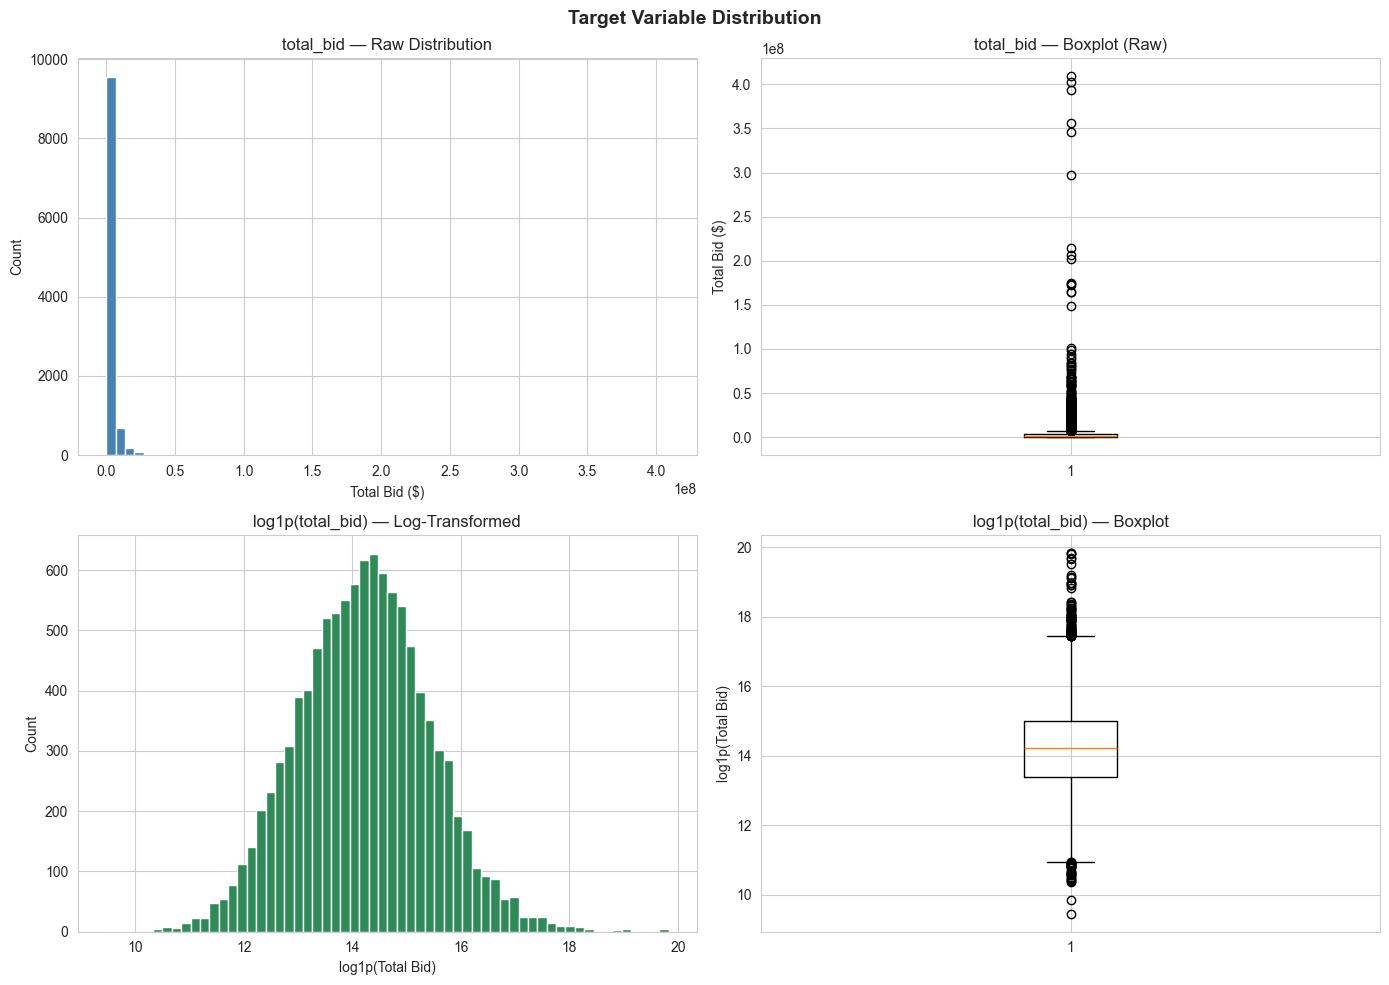

Original skewness: 21.12
Log-transformed skewness: 0.16


In [46]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].hist(df_train['total_bid'], bins=60, color='steelblue', edgecolor='white')
axes[0,0].set_title('total_bid — Raw Distribution')
axes[0,0].set_xlabel('Total Bid ($)')
axes[0,0].set_ylabel('Count')

axes[0,1].boxplot(df_train['total_bid'], vert=True)
axes[0,1].set_title('total_bid — Boxplot (Raw)')
axes[0,1].set_ylabel('Total Bid ($)')

log_bid = np.log1p(df_train['total_bid'])
axes[1,0].hist(log_bid, bins=60, color='seagreen', edgecolor='white')
axes[1,0].set_title('log1p(total_bid) — Log-Transformed')
axes[1,0].set_xlabel('log1p(Total Bid)')
axes[1,0].set_ylabel('Count')

axes[1,1].boxplot(log_bid, vert=True)
axes[1,1].set_title('log1p(total_bid) — Boxplot')
axes[1,1].set_ylabel('log1p(Total Bid)')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Original skewness: {df_train['total_bid'].skew():.2f}")
print(f"Log-transformed skewness: {log_bid.skew():.2f}")

**Insight:** `total_bid` spans nearly 5 orders of magnitude — from small maintenance jobs in the tens of thousands to major infrastructure projects in the hundreds of millions. The log-transformed distribution is approximately Gaussian with slight right skew. RMSLE is the natural metric here because it treats relative errors symmetrically: a 10% underestimate on a \$100K job and a \$10M job are penalised equally.

### 5.2 Feature Correlations with Target

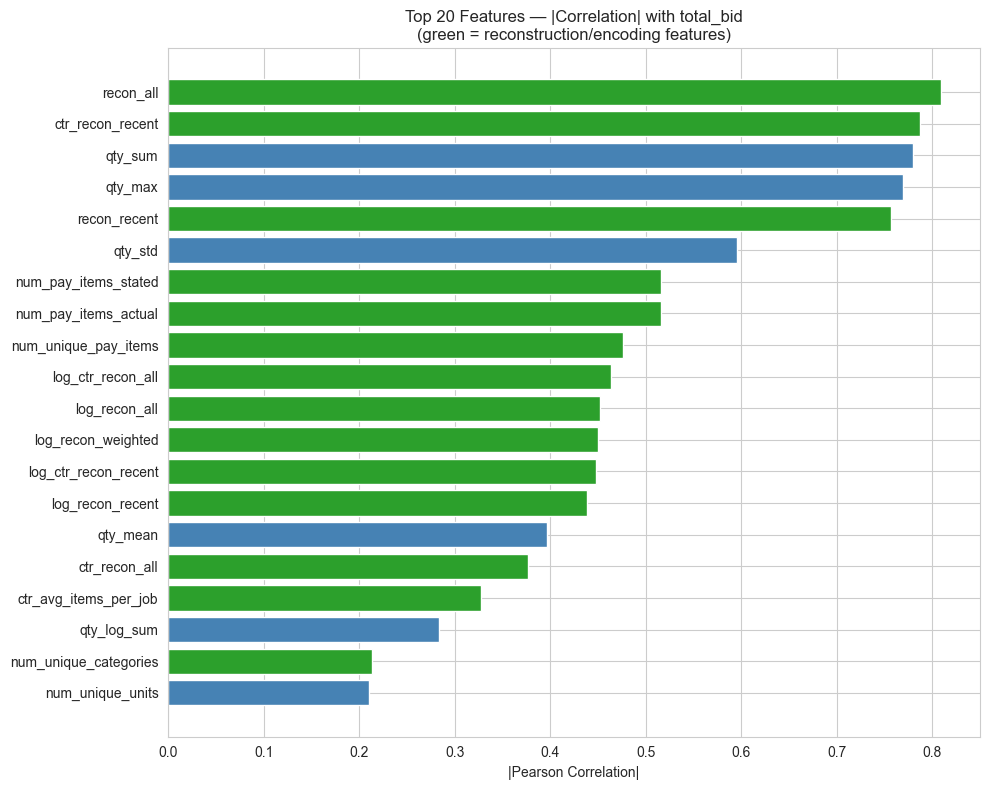

recon_all                0.810
ctr_recon_recent         0.788
qty_sum                  0.780
qty_max                  0.769
recon_recent             0.757
qty_std                  0.595
num_pay_items_stated     0.516
num_pay_items_actual     0.516
num_unique_pay_items     0.476
log_ctr_recon_all        0.464
log_recon_all            0.453
log_recon_weighted       0.450
log_ctr_recon_recent     0.448
log_recon_recent         0.438
qty_mean                 0.396
ctr_recon_all            0.376
ctr_avg_items_per_job    0.327
qty_log_sum              0.283
num_unique_categories    0.214
num_unique_units         0.211


In [47]:
numeric_feats = [c for c in df_train.select_dtypes(include='number').columns
                 if c != 'total_bid']

top_corr = (df_train[numeric_feats + ['total_bid']]
            .corr()['total_bid']
            .drop('total_bid')
            .abs()
            .sort_values(ascending=False)
            .head(20))

# Bar chart
colors = ['#2ca02c' if any(k in c for k in ['recon','te']) else 'steelblue' for c in top_corr.index]
plt.figure(figsize=(10, 8))
plt.barh(top_corr.index[::-1], top_corr.values[::-1], color=colors[::-1])
plt.title('Top 20 Features — |Correlation| with total_bid\n(green = reconstruction/encoding features)')
plt.xlabel('|Pearson Correlation|')
plt.tight_layout()
plt.show()
print(top_corr.round(3).to_string())

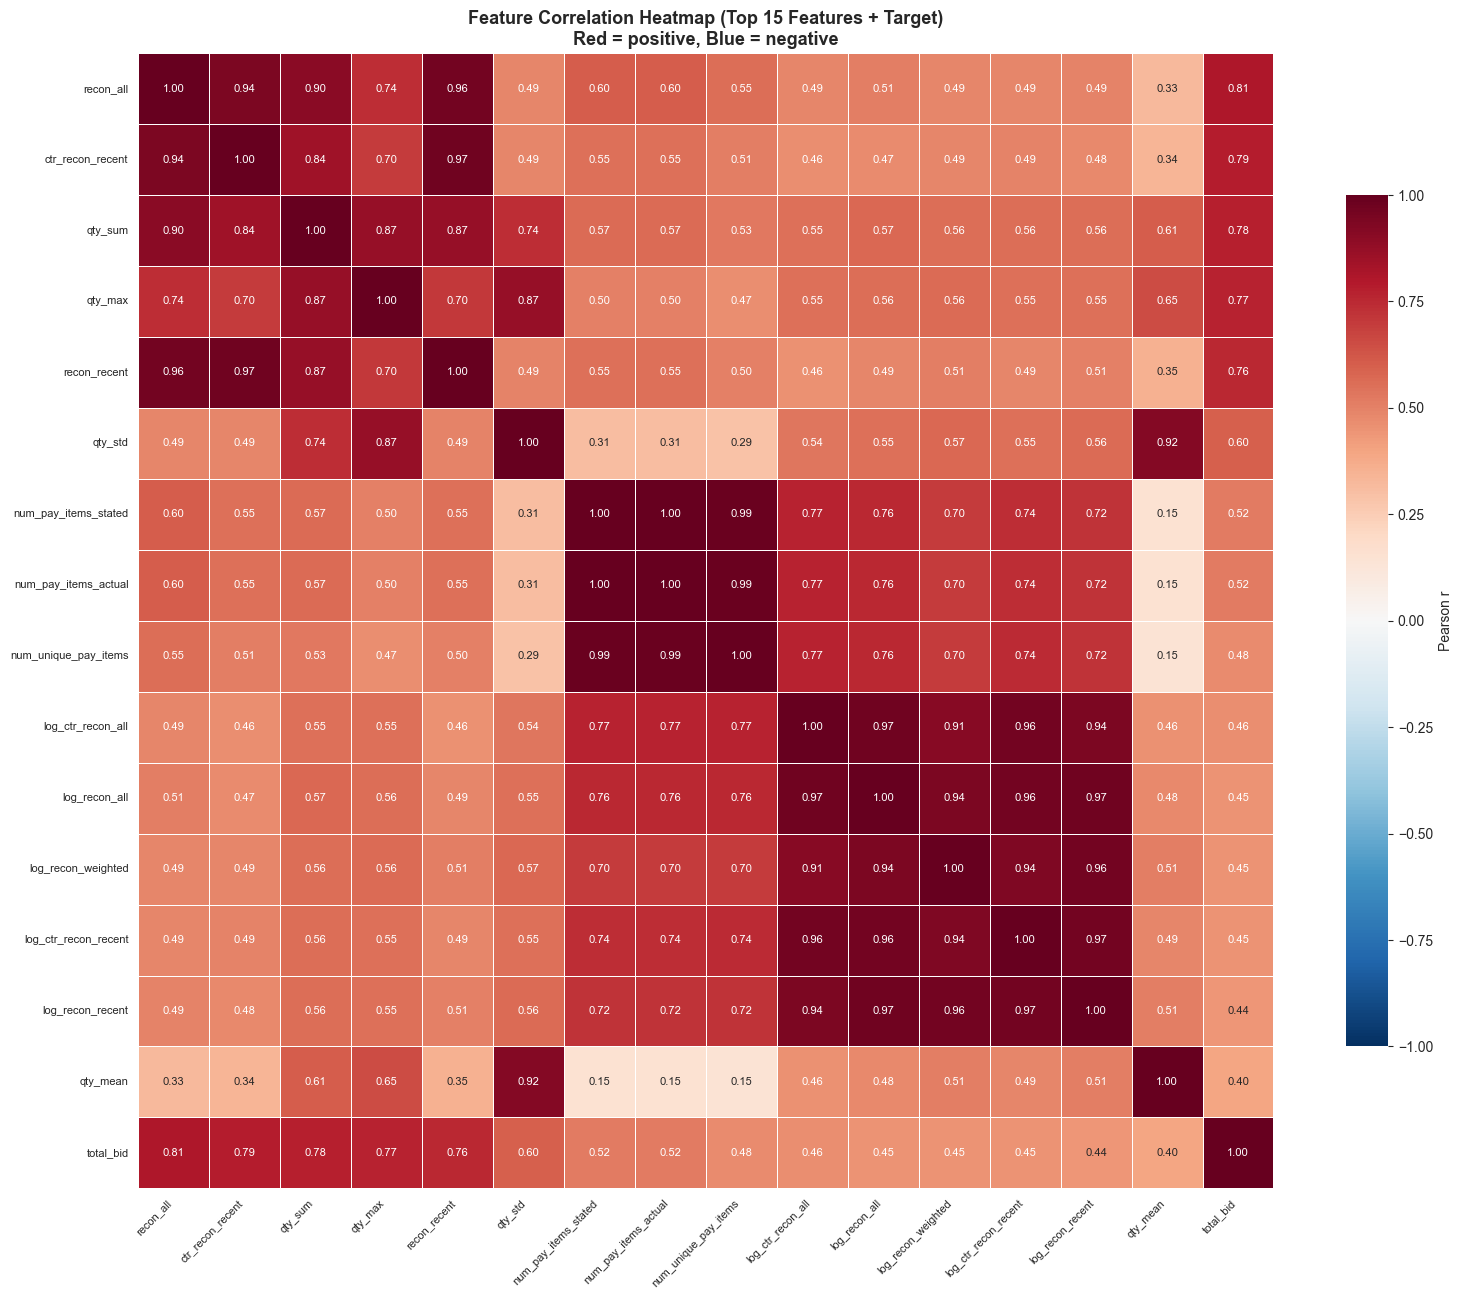

Highly correlated feature pairs (|r| > 0.90, excluding self and target):
  recon_all                      ↔  ctr_recon_recent                r = +0.943
  recon_all                      ↔  recon_recent                    r = +0.961
  ctr_recon_recent               ↔  recon_recent                    r = +0.971
  qty_std                        ↔  qty_mean                        r = +0.919
  num_pay_items_stated           ↔  num_pay_items_actual            r = +1.000
  num_pay_items_stated           ↔  num_unique_pay_items            r = +0.991
  num_pay_items_actual           ↔  num_unique_pay_items            r = +0.991
  log_ctr_recon_all              ↔  log_recon_all                   r = +0.974
  log_ctr_recon_all              ↔  log_recon_weighted              r = +0.910
  log_ctr_recon_all              ↔  log_ctr_recon_recent            r = +0.963
  log_ctr_recon_all              ↔  log_recon_recent                r = +0.938
  log_recon_all                  ↔  log_recon_weighted    

In [48]:
# Correlation heatmap — multicollinearity check among top features
top_hm_feats = top_corr.head(15).index.tolist() + ['total_bid']
corr_mx = df_train[top_hm_feats].corr()

plt.figure(figsize=(16, 13))
mask = np.zeros_like(corr_mx, dtype=bool)  # show full matrix
sns.heatmap(
    corr_mx, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, square=True,
    linewidths=0.4, linecolor='white',
    cbar_kws={'shrink': 0.75, 'label': 'Pearson r'},
    annot_kws={'size': 8}
)
plt.title('Feature Correlation Heatmap (Top 15 Features + Target)\nRed = positive, Blue = negative',
          fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Flag high multicollinearity
print("Highly correlated feature pairs (|r| > 0.90, excluding self and target):")
pairs_shown = set()
for i in corr_mx.columns:
    for j in corr_mx.columns:
        if i != j and i != 'total_bid' and j != 'total_bid':
            r = abs(corr_mx.loc[i, j])
            key = tuple(sorted([i, j]))
            if r > 0.90 and key not in pairs_shown:
                print(f"  {i:30s} ↔  {j:30s}  r = {corr_mx.loc[i,j]:+.3f}")
                pairs_shown.add(key)

**Insight — correlations:** The reconstruction features dominate — they are essentially noisy estimates of `log(total_bid)` from the supply side.

**Insight — heatmap and the residual modeling context:** High correlations among `log_recon_all`, `log_recon_recent`, `log_ctr_recon_all` look like redundancy on the heatmap, but in a residual model the interpretation flips. Our target is `log(bid) - log_recon_recent`. In that context, `log_ctr_recon_all - log_recon_recent` ≈ the contractor's own price premium over the market — which is *exactly* the residual signal. Dropping correlated reconstruction variants therefore removes the most useful contractor-pricing feature and hurts OOF RMSLE substantially (confirmed: 0.2835 → 0.3015 when dropped).

**Safe to drop**: only `num_pay_items_stated` (r=1.000 — a perfect duplicate with zero independent information). All other high-correlation pairs carry complementary contractor-level signal in the residual frame and are kept.

### 5.3 Reconstruction Comparison (All-History vs Recent vs Weighted)

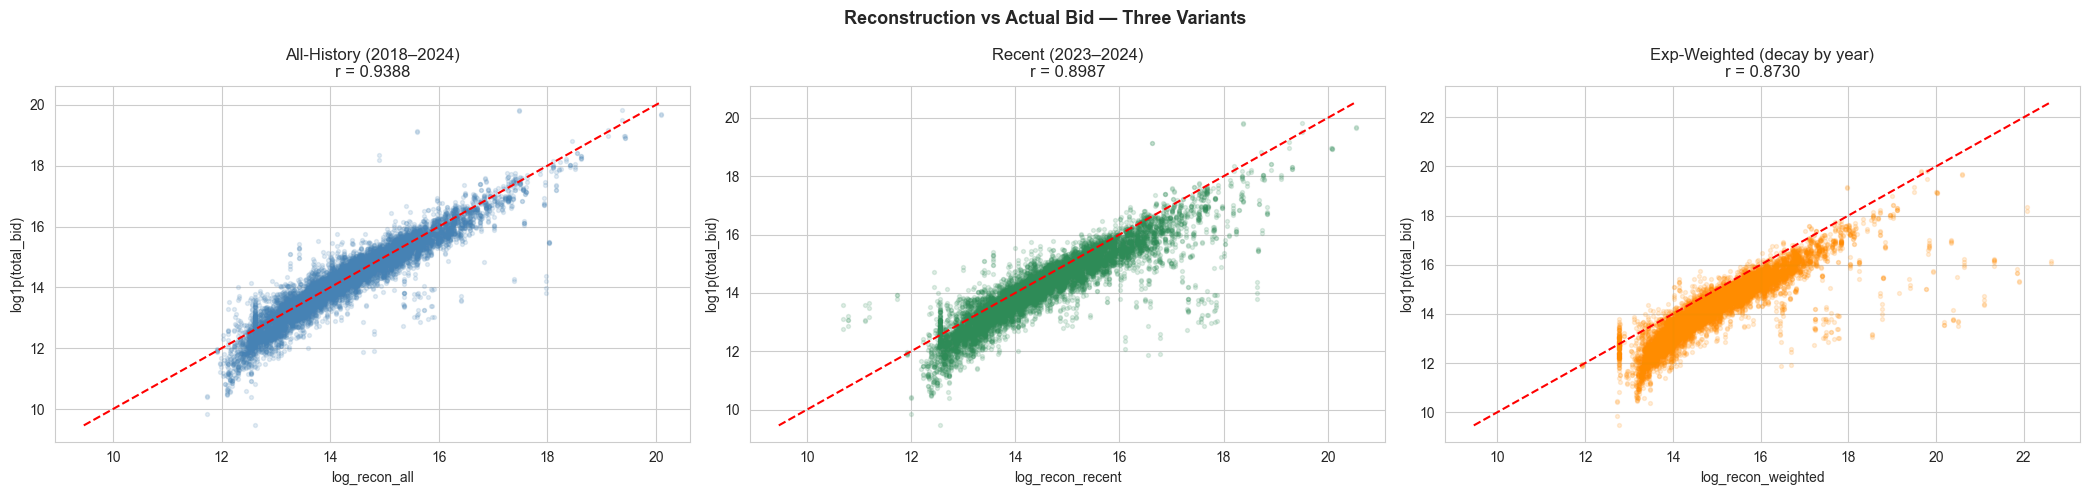

Recency ratio stats (recon_recent / recon_all):
count    10620.000
mean         1.402
std          1.396
min          0.060
25%          1.190
50%          1.260
75%          1.345
max         45.756
Name: recon_recency_ratio, dtype: float64


In [49]:
fig, axes = plt.subplots(1, 3, figsize=(21, 5))

log_actual = np.log1p(df_train['total_bid'])

for ax, col, label, color in zip(
    axes,
    ['log_recon_all', 'log_recon_recent', 'log_recon_weighted'],
    ['All-History (2018–2024)', 'Recent (2023–2024)', 'Exp-Weighted (decay by year)'],
    ['steelblue', 'seagreen', 'darkorange']
):
    ax.scatter(df_train[col], log_actual, alpha=0.15, s=8, color=color)
    mn = min(df_train[col].min(), log_actual.min())
    mx = max(df_train[col].max(), log_actual.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5)
    corr = np.corrcoef(df_train[col], log_actual)[0,1]
    ax.set_title(f'{label}\nr = {corr:.4f}')
    ax.set_xlabel(col)
    ax.set_ylabel('log1p(total_bid)')

plt.suptitle('Reconstruction vs Actual Bid — Three Variants', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Recency ratio stats (recon_recent / recon_all):")
print(df_train['recon_recency_ratio'].describe().round(3))

**Insight:** All three reconstructions show a tight linear relationship with actual bids. If `log_recon_recent` has a slightly lower correlation than `log_recon_all` (smaller sample → noisier price estimates), it is still the preferred residual baseline because it better approximates 2025 price levels. The exponentially weighted variant should sit between them: correlation close to `log_recon_all` (full coverage) but price levels closer to `log_recon_recent` (recent emphasis).

### 5.4 Categorical Analysis

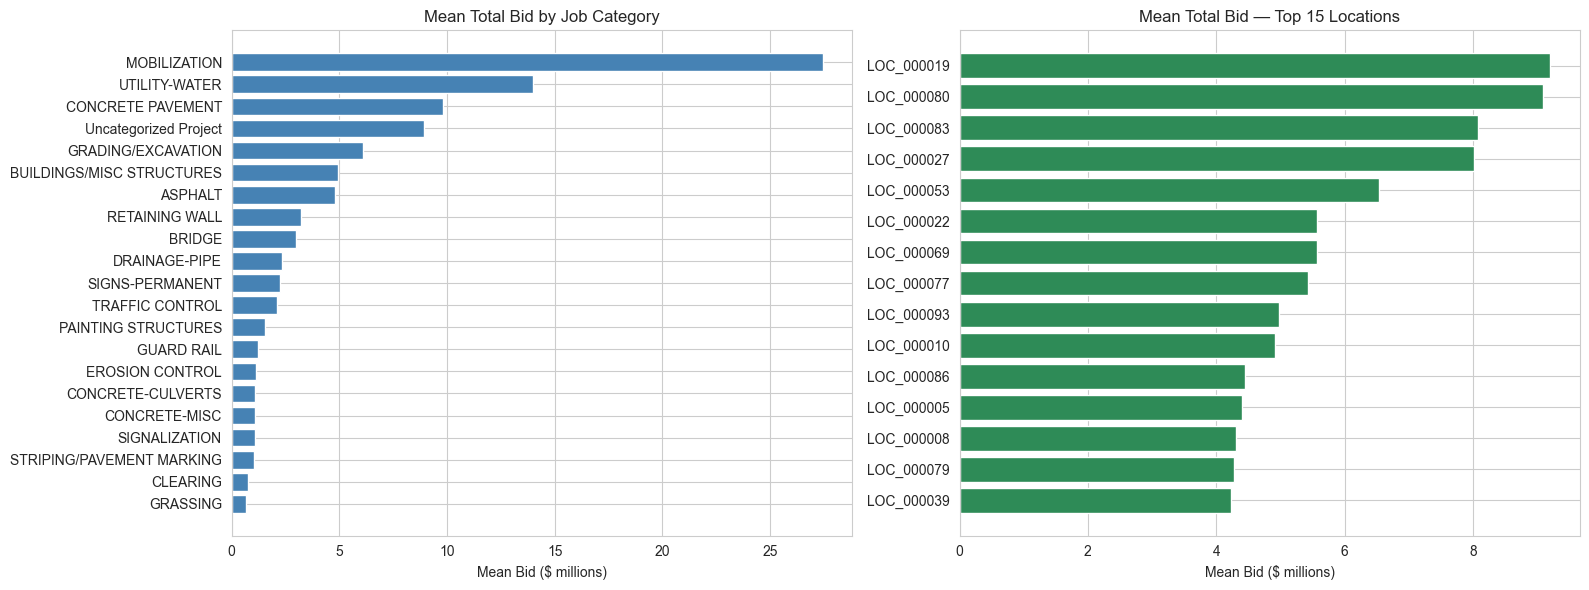

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

job_cat_mean = (df_train.groupby('job_category_orig')['total_bid']
                .mean().sort_values(ascending=True))
axes[0].barh(job_cat_mean.index, job_cat_mean.values / 1e6, color='steelblue')
axes[0].set_title('Mean Total Bid by Job Category')
axes[0].set_xlabel('Mean Bid ($ millions)')

loc_mean = (df_train.groupby('primary_location_orig')['total_bid']
            .mean().sort_values(ascending=False).head(15).sort_values(ascending=True))
axes[1].barh(loc_mean.index, loc_mean.values / 1e6, color='seagreen')
axes[1].set_title('Mean Total Bid — Top 15 Locations')
axes[1].set_xlabel('Mean Bid ($ millions)')

plt.tight_layout()
plt.show()

**Insight:** Bridge construction and major earthwork jobs average several times higher than simpler categories. Location also shows strong variation — large metropolitan areas typically see larger contracts. These patterns are captured by the k-fold target encodings (`job_cat_te`, `location_te`), which smoothly encode the historical average log-bid for each category/location.

### 5.5 Temporal Trends

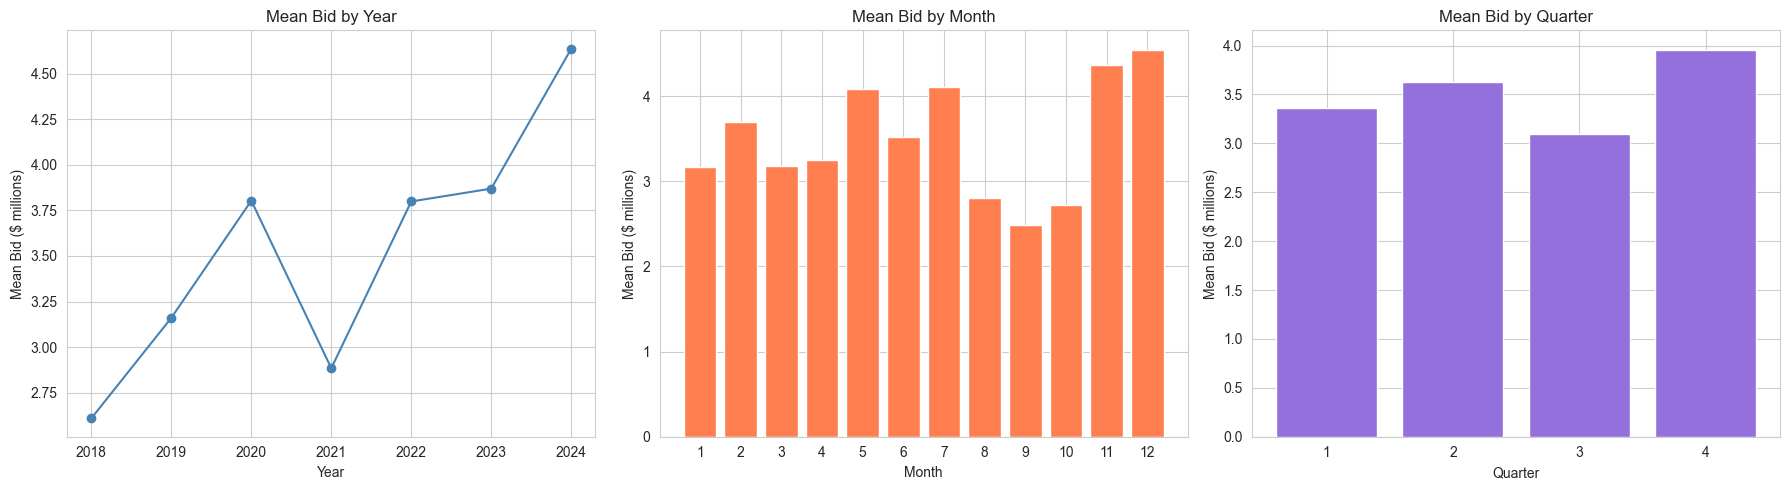

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

year_mean = df_train.groupby('bid_year')['total_bid'].mean() / 1e6
axes[0].plot(year_mean.index, year_mean.values, marker='o', color='steelblue')
axes[0].set_title('Mean Bid by Year')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Mean Bid ($ millions)')

month_mean = df_train.groupby('bid_month')['total_bid'].mean() / 1e6
axes[1].bar(month_mean.index, month_mean.values, color='coral')
axes[1].set_title('Mean Bid by Month')
axes[1].set_xlabel('Month'); axes[1].set_ylabel('Mean Bid ($ millions)')
axes[1].set_xticks(range(1,13))

quarter_mean = df_train.groupby('bid_quarter')['total_bid'].mean() / 1e6
axes[2].bar(quarter_mean.index, quarter_mean.values, color='mediumpurple')
axes[2].set_title('Mean Bid by Quarter')
axes[2].set_xlabel('Quarter'); axes[2].set_ylabel('Mean Bid ($ millions)')
axes[2].set_xticks([1,2,3,4])

plt.tight_layout()
plt.show()

**Insight:** A clear upward trend in average bids year over year, consistent with construction cost inflation of 3–7% per year. This reinforces why the reconstruction features are critical — a model trained only on 2018 data would systematically underestimate 2025 bids. v1.5's 2022+ training filter and residual modeling address this directly.

## 6. Preprocessing for Machine Learning

### 6.1 Define Features and Residual Target

**v1.5 key change — Residual Modeling:**

Instead of predicting `log1p(total_bid)` directly, we predict the *residual*:
```
y_residual = log1p(total_bid) - log_recon_recent
```
This is "how much does this contractor deviate from the recent market reconstruction?" The model only needs to learn the ±10–20% contractor-level corrections, not the full 5-order-of-magnitude price scale. This substantially reduces the model's capacity needs, reduces era overfitting, and makes the learned patterns more stable across years.

`log_recon_recent` is excluded from the feature set since it is the residual baseline (it's been subtracted from the target). All other reconstruction features remain as they encode complementary information.

In [52]:
target = 'total_bid'
NOTEBOOK_VERSION = 'v1.9'

# Raw reconstruction columns (still dropped from training features)
raw_recon_cols = ['recon_all', 'recon_recent', 'recon_weighted', 'ctr_recon_all', 'ctr_recon_recent']

# --- v1.9 robust feature additions ---
for df in [df_train, df_test]:
    # Robust ratio variants: heavy tails can destabilize tree splits.
    df['recon_recency_ratio_clip'] = df['recon_recency_ratio'].clip(lower=0.5, upper=3.0)
    df['ctr_recon_recency_ratio_clip'] = df['ctr_recon_recency_ratio'].clip(lower=0.5, upper=3.5)
    df['recon_ew_ratio_clip'] = df['recon_ew_ratio'].clip(lower=0.5, upper=3.0)

    df['recon_recency_logdev'] = np.log(df['recon_recency_ratio_clip'])
    df['ctr_recon_recency_logdev'] = np.log(df['ctr_recon_recency_ratio_clip'])
    df['recon_ew_logdev'] = np.log(df['recon_ew_ratio_clip'])

    # Blended market baseline: all-history is strongest, recent/weighted add drift signal.
    df['log_recon_blend'] = (
        0.60 * df['log_recon_all'] +
        0.25 * df['log_recon_recent'] +
        0.15 * df['log_recon_weighted']
    )

    # Residual-compatible delta features.
    df['delta_log_all_recent'] = df['log_recon_all'] - df['log_recon_recent']
    df['delta_log_weighted_recent'] = df['log_recon_weighted'] - df['log_recon_recent']
    df['delta_log_ctr_vs_job'] = df['log_ctr_recon_all'] - df['log_recon_all']

residual_baseline_col = 'log_recon_blend'

# Drop non-feature columns
drop_cols = [
    'job_id', 'contractor_id', 'row_id', 'bid_date',
    'primary_location_orig', 'job_category_orig', target,
    residual_baseline_col,
] + raw_recon_cols + [
    # keep stabilized versions, drop noisy raw ratios
    'recon_recency_ratio', 'ctr_recon_recency_ratio', 'recon_ew_ratio',
    # perfect duplicate
    'num_pay_items_stated',
]
drop_cols = [c for c in drop_cols if c in df_train.columns]

feature_cols = [
    c for c in df_train.columns
    if c not in drop_cols
    and df_train[c].dtype in ['float64', 'int64', 'int32', 'float32']
]

X_all = df_train[feature_cols].copy()
X_test_final = df_test[feature_cols].copy()

# Residual target against blended reconstruction
log_total = np.log1p(df_train[target])
y_residual_all = log_total - df_train[residual_baseline_col]

recon_baseline_train = df_train[residual_baseline_col].values
recon_baseline_test = df_test[residual_baseline_col].values

# Additional skew handling
already_log = [c for c in feature_cols if c.startswith('log_') or c == 'qty_log_sum']
skew_cols = [
    c for c in X_all.skew()[X_all.skew().abs() > 1.5].index
    if X_all[c].min() >= 0 and c not in already_log and 'ratio' not in c
]
for c in skew_cols:
    X_all[c] = np.log1p(X_all[c])
    X_test_final[c] = np.log1p(X_test_final[c])

assert X_all.isnull().sum().sum() == 0, 'Nulls in X_all'
assert X_test_final.isnull().sum().sum() == 0, 'Nulls in X_test_final'

# v1.9 uses all years with recency-weighted fitting instead of hard filtering.
X_model = X_all.reset_index(drop=True)
y_model = y_residual_all.reset_index(drop=True)
job_groups_model = df_train['job_id'].reset_index(drop=True)
recon_base_model = recon_baseline_train.copy()
y_true_log_model = log_total.reset_index(drop=True).values

# Recency weights for fitting
year_weight_map = {2024: 4.0, 2023: 2.0, 2022: 1.0, 2021: 0.5, 2020: 0.25, 2019: 0.125, 2018: 0.0625}
sample_weight_model = df_train['bid_year'].map(year_weight_map).fillna(0.03125).astype(float).values
sample_weight_model = sample_weight_model / np.mean(sample_weight_model)

# Temporal holdout slices (primary drift gate)
temporal_train_mask = (df_train['bid_year'] <= 2023).values
temporal_val_mask = (df_train['bid_year'] == 2024).values
temporal_train_idx = np.where(temporal_train_mask)[0]
temporal_val_idx = np.where(temporal_val_mask)[0]
y_temporal_true_log = y_true_log_model[temporal_val_idx]

print(f"NOTEBOOK_VERSION: {NOTEBOOK_VERSION}")
print(f"Total features: {len(feature_cols)}")
print(f"Training rows: {len(X_model)}  |  Test rows: {len(X_test_final)}")
print(f"Temporal split rows -> train<=2023: {len(temporal_train_idx)}, val=2024: {len(temporal_val_idx)}")
print(f"Additional log transforms: {len(skew_cols)}")
print()
print('Sample weight summary:')
print(pd.Series(sample_weight_model).describe().round(3).to_string())
print()
print('Feature list:')
for i, f in enumerate(feature_cols):
    print(f"  [{i:02d}] {f}")


NOTEBOOK_VERSION: v1.9
Total features: 47
Training rows: 10620  |  Test rows: 1447
Temporal split rows -> train<=2023: 9122, val=2024: 1498
Additional log transforms: 8

Sample weight summary:
count    10620.000
mean         1.000
std          1.237
min          0.058
25%          0.116
50%          0.466
75%          1.863
max          3.726

Feature list:
  [00] primary_location
  [01] job_category_description
  [02] bid_year
  [03] bid_month
  [04] bid_quarter
  [05] bid_dow_sin
  [06] bid_dow_cos
  [07] qty_sum
  [08] qty_mean
  [09] qty_std
  [10] qty_max
  [11] qty_log_sum
  [12] num_pay_items_actual
  [13] num_unique_pay_items
  [14] num_unique_units
  [15] num_unique_categories
  [16] ctr_total_jobs
  [17] ctr_avg_items_per_job
  [18] ctr_unique_units
  [19] ctr_unique_categories
  [20] ctr_win_rate
  [21] ctr_bid_ratio_mean
  [22] ctr_bid_ratio_median
  [23] ctr_bid_ratio_std
  [24] ctr_jobs_recent
  [25] ctr_win_rate_recent
  [26] ctr_recent_pct
  [27] log_recon_all
  [28] lo

### 6.2 Training Filter — 2022+ Only

Training is filtered to 2022–2024 bids before model fitting. This discards ~40% of training rows but removes the most stale price-level patterns. **Price statistics are still computed from all of `raw_train` (2018–2024)** — more data gives better price estimates. Only the model training rows are restricted.

The exponentially weighted reconstruction already soft-discounts old bids, but hard-filtering rows goes further: it prevents the model from learning that "small bids correlate with feature X" purely because 2018–2020 had smaller bids at lower price levels.

In [53]:
gkf_main = GroupKFold(n_splits=5)

# Scaling path used for linear baseline model
scaler = RobustScaler()
X_model_sc = scaler.fit_transform(X_model)
X_test_sc = scaler.transform(X_test_final)

print(f"X_model:      {X_model.shape}")
print(f"X_test_final: {X_test_final.shape}")
print('GroupKFold + temporal holdout are active in v1.9.')


X_model:      (10620, 47)
X_test_final: (1447, 47)
GroupKFold + temporal holdout are active in v1.9.


### 6.3 5-Fold GroupKFold Cross-Validation Setup

`GroupKFold(n_splits=5)` ensures all contractors from the same job stay in the same fold — correctly mirroring the test structure (entirely new jobs). Five folds give us out-of-fold (OOF) predictions covering all training rows, which:
1. Produces a stable local RMSLE estimate (vs a single GroupShuffleSplit which can vary by ±0.005)
2. Enables future stacking / meta-learning on OOF predictions

**Expected local-vs-Kaggle gap:** With `GroupKFold` the local RMSLE is harder than Kaggle's random 30% test sample. Expect local ~0.05–0.08 above the Kaggle public score. A gap that is *narrowing* over versions is the signal that era overfitting is improving.

In [54]:
gkf_main = GroupKFold(n_splits=5)

# Scaling path used for linear baseline model
scaler = RobustScaler()
X_model_sc = scaler.fit_transform(X_model)
X_test_sc = scaler.transform(X_test_final)

print(f"X_model:      {X_model.shape}")
print(f"X_test_final: {X_test_final.shape}")
print('GroupKFold + temporal holdout are active in v1.9.')


X_model:      (10620, 47)
X_test_final: (1447, 47)
GroupKFold + temporal holdout are active in v1.9.


## 7. Model Training and Evaluation

In [55]:
def compute_rmsle(y_true_log, y_pred_log):
    return float(np.sqrt(mean_squared_error(
        np.asarray(y_true_log, dtype=float),
        np.clip(np.asarray(y_pred_log, dtype=float), 0, None)
    )))


def rmsle_from_residuals(y_res_true, y_res_pred, recon_base):
    y_true_log = np.asarray(y_res_true, dtype=float) + np.asarray(recon_base, dtype=float)
    y_pred_log = np.clip(np.asarray(y_res_pred, dtype=float) + np.asarray(recon_base, dtype=float), 0, None)
    return float(np.sqrt(mean_squared_error(y_true_log, y_pred_log)))


def residual_metrics(y_res_true, y_res_pred, recon_base):
    y_true_log = np.asarray(y_res_true, dtype=float) + np.asarray(recon_base, dtype=float)
    y_pred_log = np.clip(np.asarray(y_res_pred, dtype=float) + np.asarray(recon_base, dtype=float), 0, None)
    up = np.expm1(y_pred_log)
    ut = np.expm1(y_true_log)
    return {
        'rmsle': compute_rmsle(y_true_log, y_pred_log),
        'rmse': float(np.sqrt(mean_squared_error(ut, up))),
        'mae': float(mean_absolute_error(ut, up)),
        'r2': float(r2_score(ut, up)),
    }


results = {}
val_preds = {}      # residual OOF predictions for full train
tst_preds = {}      # full log predictions for test
temporal_logs = {}  # full log predictions on temporal val (2024)
specs = {}


### 7.0 Hyperparameter Search (Optuna — Optional)

Set `RUN_OPTUNA = True` to run ~40 Bayesian trials per model on 3-fold CV (~8 minutes total).
When `False`, the pre-set params in sections 7.2 and 7.3 are used directly.

**Why Optuna over manual tuning or RandomizedSearchCV:**
- Uses TPE (Tree-structured Parzen Estimator) — learns from previous trials, concentrates search on promising regions
- Much more efficient than grid/random search for 7-dimensional spaces
- 3-fold CV per trial is fast enough with `n_estimators=1500` + early stopping

In [56]:
RUN_OPTUNA = True
OPTUNA_TRIALS_XGB = 25
OPTUNA_TRIALS_LGB = 25
OPTUNA_TRIALS_CB = 20
OPTUNA_XGB_BEST = {}
OPTUNA_LGB_BEST = {}
OPTUNA_CB_BEST = {}

if RUN_OPTUNA and not OPTUNA_AVAILABLE:
    print('Install optuna first: pip install optuna')
    RUN_OPTUNA = False

if RUN_OPTUNA:
    gkf3 = GroupKFold(n_splits=3)

    def _score_optuna(family, params):
        sec_scores = []
        for tr_i, va_i in gkf3.split(X_model, y_model, groups=job_groups_model):
            Xtr, Xva = X_model.iloc[tr_i], X_model.iloc[va_i]
            ytr, yva = y_model.iloc[tr_i], y_model.iloc[va_i]
            sw_tr = sample_weight_model[tr_i]
            rb_va = recon_base_model[va_i]

            if family == 'xgb':
                m = xgb.XGBRegressor(random_state=42, early_stopping_rounds=40, **params)
                m.fit(Xtr, ytr, sample_weight=sw_tr, eval_set=[(Xva, yva)], verbose=False)
            elif family == 'lgb':
                m = LGBMRegressor(random_state=42, **params)
                m.fit(Xtr, ytr, sample_weight=sw_tr, eval_set=[(Xva, yva)],
                      callbacks=[lgb_mod.early_stopping(40, verbose=False), lgb_mod.log_evaluation(-1)])
            else:
                m = CatBoostRegressor(random_seed=42, **params)
                m.fit(Xtr, ytr, sample_weight=sw_tr, eval_set=(Xva, yva), verbose=0)

            pred_va = np.asarray(m.predict(Xva), dtype=float)
            sec_scores.append(rmsle_from_residuals(yva, pred_va, rb_va))

        # temporal component
        if family == 'xgb':
            mt = xgb.XGBRegressor(random_state=42, **{k:v for k,v in params.items() if k != 'early_stopping_rounds'})
            mt.fit(X_model.iloc[temporal_train_idx], y_model.iloc[temporal_train_idx],
                   sample_weight=sample_weight_model[temporal_train_idx], verbose=False)
        elif family == 'lgb':
            mt = LGBMRegressor(random_state=42, **params)
            mt.fit(X_model.iloc[temporal_train_idx], y_model.iloc[temporal_train_idx],
                   sample_weight=sample_weight_model[temporal_train_idx])
        else:
            mt = CatBoostRegressor(random_seed=42, **params)
            mt.fit(X_model.iloc[temporal_train_idx], y_model.iloc[temporal_train_idx],
                   sample_weight=sample_weight_model[temporal_train_idx], verbose=0)

        pred_t = np.asarray(mt.predict(X_model.iloc[temporal_val_idx]), dtype=float)
        pred_t_log = np.clip(pred_t + recon_base_model[temporal_val_idx], 0, None)
        temp = compute_rmsle(y_temporal_true_log, pred_t_log)
        sec = float(np.mean(sec_scores))
        return 0.65 * sec + 0.35 * temp

    def obj_xgb(trial):
        p = {
            'objective': 'reg:squarederror', 'tree_method': 'hist', 'n_jobs': -1,
            'n_estimators': 1500,
            'learning_rate': trial.suggest_float('lr', 0.01, 0.06, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 7),
            'min_child_weight': trial.suggest_int('min_child', 6, 30),
            'subsample': trial.suggest_float('subsample', 0.60, 0.90),
            'colsample_bytree': trial.suggest_float('col_bytree', 0.50, 0.90),
            'colsample_bylevel': trial.suggest_float('col_bylevel', 0.60, 1.00),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.05, 5.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 20.0, log=True),
        }
        return _score_optuna('xgb', p)

    def obj_lgb(trial):
        p = {
            'objective': 'regression', 'n_jobs': -1, 'verbosity': -1,
            'n_estimators': 1500,
            'learning_rate': trial.suggest_float('lr', 0.01, 0.05, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 24, 96),
            'max_depth': trial.suggest_int('max_depth', 3, 9),
            'min_child_samples': trial.suggest_int('min_child', 25, 90),
            'subsample': trial.suggest_float('subsample', 0.60, 0.90),
            'colsample_bytree': trial.suggest_float('col_bytree', 0.50, 0.90),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.05, 5.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 20.0, log=True),
        }
        return _score_optuna('lgb', p)

    def obj_cb(trial):
        p = {
            'iterations': 1500,
            'learning_rate': trial.suggest_float('lr', 0.01, 0.06, log=True),
            'depth': trial.suggest_int('depth', 3, 7),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 20.0, log=True),
            'subsample': trial.suggest_float('subsample', 0.60, 0.90),
            'colsample_bylevel': trial.suggest_float('col_bylevel', 0.50, 0.90),
            'random_strength': trial.suggest_float('rand_strength', 0.1, 2.0),
            'od_type': 'Iter', 'od_wait': 40,
            'loss_function': 'RMSE', 'verbose': 0, 'allow_writing_files': False,
        }
        return _score_optuna('cb', p)

    print(f'Optuna XGBoost ({OPTUNA_TRIALS_XGB} trials)...')
    sx = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
    sx.optimize(obj_xgb, n_trials=OPTUNA_TRIALS_XGB, show_progress_bar=True)
    OPTUNA_XGB_BEST = sx.best_params

    print(f'Optuna LightGBM ({OPTUNA_TRIALS_LGB} trials)...')
    sl = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
    sl.optimize(obj_lgb, n_trials=OPTUNA_TRIALS_LGB, show_progress_bar=True)
    OPTUNA_LGB_BEST = sl.best_params

    if CATBOOST_AVAILABLE:
        print(f'Optuna CatBoost ({OPTUNA_TRIALS_CB} trials)...')
        sc = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
        sc.optimize(obj_cb, n_trials=OPTUNA_TRIALS_CB, show_progress_bar=True)
        OPTUNA_CB_BEST = sc.best_params
    else:
        OPTUNA_CB_BEST = {}

    print('Optuna complete. Best params will be applied in model cells.')
else:
    print('Optuna skipped in v1.9 (RUN_OPTUNA=False).')


Optuna XGBoost (25 trials)...


Best trial: 21. Best value: 0.249405: 100%|██████████| 25/25 [07:46<00:00, 18.67s/it]


Optuna LightGBM (25 trials)...


Best trial: 17. Best value: 0.252418: 100%|██████████| 25/25 [18:30<00:00, 44.41s/it]


Optuna CatBoost (20 trials)...


Best trial: 18. Best value: 0.247697: 100%|██████████| 20/20 [03:01<00:00,  9.08s/it]

Optuna complete. Best params will be applied in model cells.


### 7.1 Ridge Regression (Linear Baseline)

In [57]:
ridge = Ridge(alpha=10.0, random_state=42)

oof_ridge = np.zeros(len(X_model))
fold_rmsle_ridge = []
for fold, (tr_i, va_i) in enumerate(gkf_main.split(X_model_sc, y_model, groups=job_groups_model)):
    X_tr, X_va = X_model_sc[tr_i], X_model_sc[va_i]
    y_tr, y_va = y_model.iloc[tr_i], y_model.iloc[va_i]
    sw_tr = sample_weight_model[tr_i]
    rb_va = recon_base_model[va_i]

    ridge.fit(X_tr, y_tr, sample_weight=sw_tr)
    vp = ridge.predict(X_va)
    oof_ridge[va_i] = vp
    fr = rmsle_from_residuals(y_va, vp, rb_va)
    fold_rmsle_ridge.append(fr)

# temporal holdout
sc_t = RobustScaler()
X_tt = sc_t.fit_transform(X_model.iloc[temporal_train_idx])
X_tv = sc_t.transform(X_model.iloc[temporal_val_idx])
ridge_t = Ridge(alpha=10.0, random_state=42)
ridge_t.fit(X_tt, y_model.iloc[temporal_train_idx], sample_weight=sample_weight_model[temporal_train_idx])
vp_temp = ridge_t.predict(X_tv)
vp_temp_log = np.clip(vp_temp + recon_base_model[temporal_val_idx], 0, None)
temporal_logs['Ridge'] = vp_temp_log

# full retrain prediction for test
ridge_full = Ridge(alpha=10.0, random_state=42)
ridge_full.fit(X_model_sc, y_model, sample_weight=sample_weight_model)
tp_log = np.clip(ridge_full.predict(X_test_sc) + recon_baseline_test, 0, None)

m = residual_metrics(y_model, oof_ridge, recon_base_model)
temp_rmsle = compute_rmsle(y_temporal_true_log, vp_temp_log)
temp_mae = float(mean_absolute_error(np.expm1(y_temporal_true_log), np.expm1(vp_temp_log)))
combined = 0.65 * m['rmsle'] + 0.35 * temp_rmsle

results['Ridge'] = {
    'Model': 'Ridge', 'RMSLE': round(m['rmsle'], 4), 'RMSE': round(m['rmse'], 2),
    'MAE': round(m['mae'], 2), 'R2': round(m['r2'], 4),
    'Temporal_RMSLE': round(temp_rmsle, 4), 'Temporal_MAE': round(temp_mae, 2),
    'CombinedScore': round(combined, 4), 'FoldStd': round(float(np.std(fold_rmsle_ridge)), 4),
}
val_preds['Ridge'] = oof_ridge
tst_preds['Ridge'] = tp_log

print(f"Ridge -> RMSLE={m['rmsle']:.4f} | Temporal={temp_rmsle:.4f} | Combined={combined:.4f}")


Ridge -> RMSLE=0.3084 | Temporal=0.2763 | Combined=0.2971


### 7.2 XGBoost (Primary Booster) — 5-Fold OOF

If `RUN_OPTUNA=True` was run in 7.0, the params dictionary is updated with Optuna best values.
Default params are from v1.5d (confirmed as a good baseline — further tightening caused regression).

In [58]:
XGB_P = {
    'objective': 'reg:squarederror',
    'tree_method': 'hist',
    'n_estimators': 2200,
    'learning_rate': 0.025,
    'max_depth': 5,
    'min_child_weight': 10,
    'subsample': 0.85,
    'colsample_bytree': 0.75,
    'colsample_bylevel': 0.80,
    'reg_alpha': 0.8,
    'reg_lambda': 8.0,
    'n_jobs': -1,
}
if OPTUNA_XGB_BEST:
    lr_key = 'lr' if 'lr' in OPTUNA_XGB_BEST else 'learning_rate'
    XGB_P.update({
        'learning_rate': OPTUNA_XGB_BEST.get(lr_key, XGB_P['learning_rate']),
        'max_depth': OPTUNA_XGB_BEST.get('max_depth', XGB_P['max_depth']),
        'min_child_weight': OPTUNA_XGB_BEST.get('min_child', XGB_P['min_child_weight']),
        'subsample': OPTUNA_XGB_BEST.get('subsample', XGB_P['subsample']),
        'colsample_bytree': OPTUNA_XGB_BEST.get('col_bytree', XGB_P['colsample_bytree']),
        'colsample_bylevel': OPTUNA_XGB_BEST.get('col_bylevel', XGB_P['colsample_bylevel']),
        'reg_alpha': OPTUNA_XGB_BEST.get('reg_alpha', XGB_P['reg_alpha']),
        'reg_lambda': OPTUNA_XGB_BEST.get('reg_lambda', XGB_P['reg_lambda']),
    })
    print('XGB_P updated with Optuna best params.')
XGB_SEEDS = [42, 123, 2024]

oof_xgb = np.zeros(len(X_model))
tst_xgb_folds = []
fold_rmsles = []
best_rounds = []

for fold, (tr_i, va_i) in enumerate(gkf_main.split(X_model, y_model, groups=job_groups_model)):
    X_tr, X_va = X_model.iloc[tr_i], X_model.iloc[va_i]
    y_tr, y_va = y_model.iloc[tr_i], y_model.iloc[va_i]
    sw_tr = sample_weight_model[tr_i]
    rb_va = recon_base_model[va_i]

    seed_vp, seed_tp = [], []
    for seed in XGB_SEEDS:
        m = xgb.XGBRegressor(random_state=seed, early_stopping_rounds=70, **XGB_P)
        m.fit(X_tr, y_tr, sample_weight=sw_tr, eval_set=[(X_va, y_va)], verbose=False)
        seed_vp.append(m.predict(X_va))
        seed_tp.append(m.predict(X_test_final))
        best_rounds.append(m.best_iteration if m.best_iteration is not None else XGB_P['n_estimators'])

    vp = np.mean(np.vstack(seed_vp), axis=0)
    tp = np.mean(np.vstack(seed_tp), axis=0)
    oof_xgb[va_i] = vp
    tst_xgb_folds.append(tp)

    fr = rmsle_from_residuals(y_va, vp, rb_va)
    fold_rmsles.append(fr)

xgb_best_n = max(100, int(np.mean(best_rounds)))
tst_xgb_log = np.clip(np.mean(np.vstack(tst_xgb_folds), axis=0) + recon_baseline_test, 0, None)

# temporal holdout
temp_seed = []
for seed in XGB_SEEDS:
    mt = xgb.XGBRegressor(random_state=seed, n_estimators=xgb_best_n, **{k:v for k,v in XGB_P.items() if k!='n_estimators'})
    mt.fit(X_model.iloc[temporal_train_idx], y_model.iloc[temporal_train_idx], sample_weight=sample_weight_model[temporal_train_idx], verbose=False)
    temp_seed.append(mt.predict(X_model.iloc[temporal_val_idx]))
vp_temp = np.mean(np.vstack(temp_seed), axis=0)
vp_temp_log = np.clip(vp_temp + recon_base_model[temporal_val_idx], 0, None)
temporal_logs['XGBoost'] = vp_temp_log

m = residual_metrics(y_model, oof_xgb, recon_base_model)
temp_rmsle = compute_rmsle(y_temporal_true_log, vp_temp_log)
temp_mae = float(mean_absolute_error(np.expm1(y_temporal_true_log), np.expm1(vp_temp_log)))
combined = 0.65 * m['rmsle'] + 0.35 * temp_rmsle

results['XGBoost'] = {
    'Model': 'XGBoost', 'RMSLE': round(m['rmsle'], 4), 'RMSE': round(m['rmse'], 2),
    'MAE': round(m['mae'], 2), 'R2': round(m['r2'], 4),
    'Temporal_RMSLE': round(temp_rmsle, 4), 'Temporal_MAE': round(temp_mae, 2),
    'CombinedScore': round(combined, 4), 'FoldStd': round(float(np.std(fold_rmsles)), 4),
}
val_preds['XGBoost'] = oof_xgb
tst_preds['XGBoost'] = tst_xgb_log
specs['XGBoost'] = {'family':'xgb', 'params':XGB_P, 'seeds':XGB_SEEDS, 'best_n':xgb_best_n}

print(f"XGBoost -> RMSLE={m['rmsle']:.4f} | Temporal={temp_rmsle:.4f} | Combined={combined:.4f} | best_n={xgb_best_n}")


XGB_P updated with Optuna best params.
XGBoost -> RMSLE=0.2568 | Temporal=0.2373 | Combined=0.2500 | best_n=747


### 7.3 LightGBM (Secondary Booster) — 5-Fold OOF

Leaf-wise tree growth gives complementary split behavior to XGBoost. `num_leaves=50` on
~3300 training rows per fold is relatively expressive — this is intentional; we confirmed
in v1.5b/c that reducing to 24 leaves hurt more than it helped.

In [59]:
LGBM_P = {
    'objective': 'regression',
    'n_estimators': 2200,
    'learning_rate': 0.022,
    'num_leaves': 64,
    'max_depth': -1,
    'min_child_samples': 40,
    'subsample': 0.85,
    'colsample_bytree': 0.75,
    'reg_alpha': 0.2,
    'reg_lambda': 4.0,
    'n_jobs': -1,
    'verbosity': -1,
}
if OPTUNA_LGB_BEST:
    lr_key = 'lr' if 'lr' in OPTUNA_LGB_BEST else 'learning_rate'
    LGBM_P.update({
        'learning_rate': OPTUNA_LGB_BEST.get(lr_key, LGBM_P['learning_rate']),
        'num_leaves': OPTUNA_LGB_BEST.get('num_leaves', LGBM_P['num_leaves']),
        'max_depth': OPTUNA_LGB_BEST.get('max_depth', LGBM_P['max_depth']),
        'min_child_samples': OPTUNA_LGB_BEST.get('min_child', LGBM_P['min_child_samples']),
        'subsample': OPTUNA_LGB_BEST.get('subsample', LGBM_P['subsample']),
        'colsample_bytree': OPTUNA_LGB_BEST.get('col_bytree', LGBM_P['colsample_bytree']),
        'reg_alpha': OPTUNA_LGB_BEST.get('reg_alpha', LGBM_P['reg_alpha']),
        'reg_lambda': OPTUNA_LGB_BEST.get('reg_lambda', LGBM_P['reg_lambda']),
    })
    print('LGBM_P updated with Optuna best params.')
LGBM_SEEDS = [42, 123, 2024]

oof_lgb = np.zeros(len(X_model))
tst_lgb_folds = []
fold_rmsles = []
best_rounds = []

for fold, (tr_i, va_i) in enumerate(gkf_main.split(X_model, y_model, groups=job_groups_model)):
    X_tr, X_va = X_model.iloc[tr_i], X_model.iloc[va_i]
    y_tr, y_va = y_model.iloc[tr_i], y_model.iloc[va_i]
    sw_tr = sample_weight_model[tr_i]
    rb_va = recon_base_model[va_i]

    seed_vp, seed_tp = [], []
    for seed in LGBM_SEEDS:
        m = LGBMRegressor(random_state=seed, **LGBM_P)
        m.fit(X_tr, y_tr, sample_weight=sw_tr, eval_set=[(X_va, y_va)],
              callbacks=[lgb_mod.early_stopping(70, verbose=False), lgb_mod.log_evaluation(-1)])
        seed_vp.append(m.predict(X_va))
        seed_tp.append(m.predict(X_test_final))
        best_rounds.append(m.best_iteration_ if m.best_iteration_ is not None else LGBM_P['n_estimators'])

    vp = np.mean(np.vstack(seed_vp), axis=0)
    tp = np.mean(np.vstack(seed_tp), axis=0)
    oof_lgb[va_i] = vp
    tst_lgb_folds.append(tp)

    fr = rmsle_from_residuals(y_va, vp, rb_va)
    fold_rmsles.append(fr)

lgb_best_n = max(100, int(np.mean(best_rounds)))
tst_lgb_log = np.clip(np.mean(np.vstack(tst_lgb_folds), axis=0) + recon_baseline_test, 0, None)

# temporal holdout
temp_seed = []
for seed in LGBM_SEEDS:
    mt = LGBMRegressor(random_state=seed, n_estimators=lgb_best_n, **{k:v for k,v in LGBM_P.items() if k!='n_estimators'})
    mt.fit(X_model.iloc[temporal_train_idx], y_model.iloc[temporal_train_idx], sample_weight=sample_weight_model[temporal_train_idx])
    temp_seed.append(mt.predict(X_model.iloc[temporal_val_idx]))
vp_temp = np.mean(np.vstack(temp_seed), axis=0)
vp_temp_log = np.clip(vp_temp + recon_base_model[temporal_val_idx], 0, None)
temporal_logs['LightGBM'] = vp_temp_log

m = residual_metrics(y_model, oof_lgb, recon_base_model)
temp_rmsle = compute_rmsle(y_temporal_true_log, vp_temp_log)
temp_mae = float(mean_absolute_error(np.expm1(y_temporal_true_log), np.expm1(vp_temp_log)))
combined = 0.65 * m['rmsle'] + 0.35 * temp_rmsle

results['LightGBM'] = {
    'Model': 'LightGBM', 'RMSLE': round(m['rmsle'], 4), 'RMSE': round(m['rmse'], 2),
    'MAE': round(m['mae'], 2), 'R2': round(m['r2'], 4),
    'Temporal_RMSLE': round(temp_rmsle, 4), 'Temporal_MAE': round(temp_mae, 2),
    'CombinedScore': round(combined, 4), 'FoldStd': round(float(np.std(fold_rmsles)), 4),
}
val_preds['LightGBM'] = oof_lgb
tst_preds['LightGBM'] = tst_lgb_log
specs['LightGBM'] = {'family':'lgbm', 'params':LGBM_P, 'seeds':LGBM_SEEDS, 'best_n':lgb_best_n}

print(f"LightGBM -> RMSLE={m['rmsle']:.4f} | Temporal={temp_rmsle:.4f} | Combined={combined:.4f} | best_n={lgb_best_n}")


LGBM_P updated with Optuna best params.
LightGBM -> RMSLE=0.2586 | Temporal=0.2388 | Combined=0.2516 | best_n=1306


### 7.4 CatBoost (Third Booster) — 5-Fold OOF

CatBoost uses **symmetric (oblivious) trees** — each level uses the same split condition for
every node. This is structurally different from XGBoost and LightGBM's asymmetric trees,
meaning CatBoost's errors are *less correlated* with theirs. This is exactly what makes
it valuable for stacking: uncorrelated errors cancel out in the meta-model.

CatBoost's overfitting detection uses `od_type='Iter'` + `od_wait` in the constructor
(the native CatBoost way). No `early_stopping_rounds` argument in `fit()`.

In [60]:
if not CATBOOST_AVAILABLE:
    print('CatBoost not available; using XGBoost fallback predictions.')
    results['CatBoost (fallback=XGB)'] = {
        **results['XGBoost'],
        'Model': 'CatBoost (fallback=XGB)'
    }
    val_preds['CatBoost'] = val_preds['XGBoost'].copy()
    tst_preds['CatBoost'] = tst_preds['XGBoost'].copy()
    temporal_logs['CatBoost'] = temporal_logs['XGBoost'].copy()
    specs['CatBoost'] = {'family':'cb', 'best_n':specs['XGBoost']['best_n'], 'params':{}, 'seeds':[42]}
else:
    CB_P = {
        'iterations': 2400,
        'learning_rate': 0.025,
        'depth': 5,
        'l2_leaf_reg': 10.0,
        'subsample': 0.85,
        'colsample_bylevel': 0.75,
        'random_strength': 0.8,
        'od_type': 'Iter',
        'od_wait': 80,
        'loss_function': 'RMSE',
        'verbose': 0,
        'allow_writing_files': False,
    }
    if OPTUNA_CB_BEST:
        lr_key = 'lr' if 'lr' in OPTUNA_CB_BEST else 'learning_rate'
        CB_P.update({
            'learning_rate': OPTUNA_CB_BEST.get(lr_key, CB_P['learning_rate']),
            'depth': OPTUNA_CB_BEST.get('depth', CB_P['depth']),
            'l2_leaf_reg': OPTUNA_CB_BEST.get('l2_leaf_reg', CB_P['l2_leaf_reg']),
            'subsample': OPTUNA_CB_BEST.get('subsample', CB_P['subsample']),
            'colsample_bylevel': OPTUNA_CB_BEST.get('col_bylevel', CB_P['colsample_bylevel']),
            'random_strength': OPTUNA_CB_BEST.get('rand_strength', CB_P['random_strength']),
        })
        print('CB_P updated with Optuna best params.')
    CB_SEEDS = [42, 123, 2024]

    oof_cb = np.zeros(len(X_model))
    tst_cb_folds = []
    fold_rmsles = []
    best_iters = []

    for fold, (tr_i, va_i) in enumerate(gkf_main.split(X_model, y_model, groups=job_groups_model)):
        X_tr, X_va = X_model.iloc[tr_i], X_model.iloc[va_i]
        y_tr, y_va = y_model.iloc[tr_i], y_model.iloc[va_i]
        sw_tr = sample_weight_model[tr_i]
        rb_va = recon_base_model[va_i]

        seed_vp, seed_tp = [], []
        for seed in CB_SEEDS:
            m = CatBoostRegressor(random_seed=seed, **CB_P)
            m.fit(X_tr, y_tr, sample_weight=sw_tr, eval_set=(X_va, y_va), verbose=0)
            seed_vp.append(m.predict(X_va))
            seed_tp.append(m.predict(X_test_final))
            best_iters.append(m.best_iteration_ if m.best_iteration_ is not None else CB_P['iterations'])

        vp = np.mean(np.vstack(seed_vp), axis=0)
        tp = np.mean(np.vstack(seed_tp), axis=0)
        oof_cb[va_i] = vp
        tst_cb_folds.append(tp)

        fr = rmsle_from_residuals(y_va, vp, rb_va)
        fold_rmsles.append(fr)

    cb_best_n = max(100, int(np.mean(best_iters)))
    tst_cb_log = np.clip(np.mean(np.vstack(tst_cb_folds), axis=0) + recon_baseline_test, 0, None)

    # temporal holdout
    temp_seed = []
    for seed in CB_SEEDS:
        mt = CatBoostRegressor(random_seed=seed, iterations=cb_best_n,
                               **{k:v for k,v in CB_P.items() if k!='iterations'})
        mt.fit(X_model.iloc[temporal_train_idx], y_model.iloc[temporal_train_idx],
               sample_weight=sample_weight_model[temporal_train_idx], verbose=0)
        temp_seed.append(mt.predict(X_model.iloc[temporal_val_idx]))
    vp_temp = np.mean(np.vstack(temp_seed), axis=0)
    vp_temp_log = np.clip(vp_temp + recon_base_model[temporal_val_idx], 0, None)
    temporal_logs['CatBoost'] = vp_temp_log

    m = residual_metrics(y_model, oof_cb, recon_base_model)
    temp_rmsle = compute_rmsle(y_temporal_true_log, vp_temp_log)
    temp_mae = float(mean_absolute_error(np.expm1(y_temporal_true_log), np.expm1(vp_temp_log)))
    combined = 0.65 * m['rmsle'] + 0.35 * temp_rmsle

    results['CatBoost'] = {
        'Model': 'CatBoost', 'RMSLE': round(m['rmsle'], 4), 'RMSE': round(m['rmse'], 2),
        'MAE': round(m['mae'], 2), 'R2': round(m['r2'], 4),
        'Temporal_RMSLE': round(temp_rmsle, 4), 'Temporal_MAE': round(temp_mae, 2),
        'CombinedScore': round(combined, 4), 'FoldStd': round(float(np.std(fold_rmsles)), 4),
    }
    val_preds['CatBoost'] = oof_cb
    tst_preds['CatBoost'] = tst_cb_log
    specs['CatBoost'] = {'family':'cb', 'params':CB_P, 'seeds':CB_SEEDS, 'best_n':cb_best_n}

    print(f"CatBoost -> RMSLE={m['rmsle']:.4f} | Temporal={temp_rmsle:.4f} | Combined={combined:.4f} | best_n={cb_best_n}")


CB_P updated with Optuna best params.
CatBoost -> RMSLE=0.2557 | Temporal=0.2351 | Combined=0.2485 | best_n=1569


### 7.5 Base Model Comparison (Before Stacking)

   Model  RMSLE  Temporal_RMSLE  CombinedScore  FoldStd       RMSE       MAE     R2
CatBoost 0.2557          0.2351         0.2485   0.0154 5222354.25 599928.82 0.8033
 XGBoost 0.2568          0.2373         0.2500   0.0163 5218740.21 633499.00 0.8036
LightGBM 0.2586          0.2388         0.2516   0.0163 5414817.25 632852.64 0.7885
   Ridge 0.3084          0.2763         0.2971   0.0131 5093167.89 781183.00 0.8129


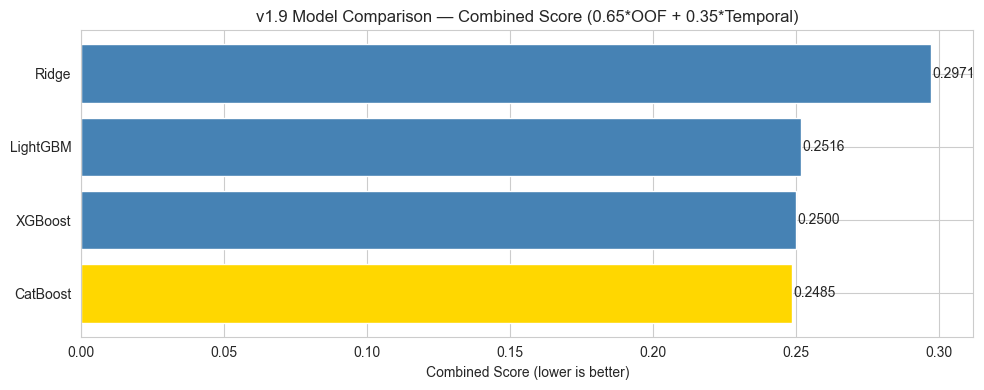

In [61]:
results_df = pd.DataFrame(list(results.values())).sort_values('CombinedScore').reset_index(drop=True)
print(results_df[['Model','RMSLE','Temporal_RMSLE','CombinedScore','FoldStd','RMSE','MAE','R2']].to_string(index=False))

plt.figure(figsize=(10, 4))
bars = plt.barh(results_df['Model'], results_df['CombinedScore'], color=['gold'] + ['steelblue'] * (len(results_df)-1))
plt.title('v1.9 Model Comparison — Combined Score (0.65*OOF + 0.35*Temporal)')
plt.xlabel('Combined Score (lower is better)')
for b,v in zip(bars, results_df['CombinedScore']):
    plt.text(v + 0.0005, b.get_y()+b.get_height()/2, f'{v:.4f}', va='center')
plt.tight_layout(); plt.show()


### 7.6 Stacking — Ridge Meta-Model on OOF Predictions

**Why stacking works here:**
- XGBoost, LightGBM, CatBoost each make different kinds of errors (different tree structures)
- A meta Ridge learns the optimal combination: "when XGB is confident and CB disagrees, trust XGB more"
- The OOF predictions are **leakage-free** — each was made on held-out data → safe to train meta on them

**Why Ridge (not another tree) as the meta-model:**
- Only 3 meta-features (one per base model) — no benefit from non-linearity
- Ridge with tuned alpha avoids overweighting any single model

**Honest RMSLE:** We use inner 5-fold GroupKFold on the meta-features to get a leakage-free RMSLE for the stacked model. Fitting meta on ALL OOF for the final model is standard Kaggle practice.

In [62]:
# RobustBlend optimization over base models
base_models = [m for m in ['XGBoost','LightGBM','CatBoost'] if m in val_preds and m in temporal_logs]

blend_weights = None
if len(base_models) >= 2:
    best = {'score': np.inf}

    if len(base_models) == 2:
        for w0 in np.arange(0, 1.001, 0.05):
            ws = np.array([w0, 1-w0])
            sec_log = np.zeros(len(y_true_log_model))
            temp_log = np.zeros(len(y_temporal_true_log))
            test_log = np.zeros(len(recon_baseline_test))
            for w, m in zip(ws, base_models):
                sec_log += w * np.clip(val_preds[m] + recon_base_model, 0, None)
                temp_log += w * temporal_logs[m]
                test_log += w * tst_preds[m]
            sec_r = compute_rmsle(y_true_log_model, sec_log)
            tmp_r = compute_rmsle(y_temporal_true_log, temp_log)
            score = 0.65 * sec_r + 0.35 * tmp_r
            if score < best['score']:
                best = {'score': score, 'sec': sec_r, 'temp': tmp_r, 'ws': ws, 'sec_log': sec_log, 'test_log': test_log}
    else:
        for w0 in np.arange(0, 1.001, 0.05):
            for w1 in np.arange(0, 1.001 - w0, 0.05):
                w2 = 1 - w0 - w1
                if w2 < -1e-9:
                    continue
                ws = np.array([w0, w1, w2])
                sec_log = np.zeros(len(y_true_log_model))
                temp_log = np.zeros(len(y_temporal_true_log))
                test_log = np.zeros(len(recon_baseline_test))
                for w, m in zip(ws, base_models):
                    sec_log += w * np.clip(val_preds[m] + recon_base_model, 0, None)
                    temp_log += w * temporal_logs[m]
                    test_log += w * tst_preds[m]
                sec_r = compute_rmsle(y_true_log_model, sec_log)
                tmp_r = compute_rmsle(y_temporal_true_log, temp_log)
                score = 0.65 * sec_r + 0.35 * tmp_r
                if score < best['score']:
                    best = {'score': score, 'sec': sec_r, 'temp': tmp_r, 'ws': ws, 'sec_log': sec_log, 'test_log': test_log}

    blend_weights = {m: float(w) for m, w in zip(base_models, best['ws'])}
    val_preds['RobustBlend'] = best['sec_log'] - recon_base_model
    tst_preds['RobustBlend'] = np.clip(best['test_log'], 0, None)
    results['RobustBlend'] = {
        'Model': 'RobustBlend',
        'RMSLE': round(float(best['sec']), 4),
        'RMSE': np.nan,
        'MAE': np.nan,
        'R2': np.nan,
        'Temporal_RMSLE': round(float(best['temp']), 4),
        'Temporal_MAE': np.nan,
        'CombinedScore': round(float(best['score']), 4),
        'FoldStd': round(float(np.mean([results[m]['FoldStd'] for m in base_models])), 4),
    }
    print('RobustBlend weights:', blend_weights)
    print(f"RobustBlend -> OOF={best['sec']:.4f} | Temporal={best['temp']:.4f} | Combined={best['score']:.4f}")
else:
    print('RobustBlend skipped: need at least 2 base models.')


RobustBlend weights: {'XGBoost': 0.30000000000000004, 'LightGBM': 0.15000000000000002, 'CatBoost': 0.5499999999999999}
RobustBlend -> OOF=0.2544 | Temporal=0.2345 | Combined=0.2474


### 7.7 Final Model Comparison (Including Stacked)

      Model  RMSLE  Temporal_RMSLE  CombinedScore  FoldStd       RMSE       MAE     R2
RobustBlend 0.2544          0.2345         0.2474   0.0160        NaN       NaN    NaN
   CatBoost 0.2557          0.2351         0.2485   0.0154 5222354.25 599928.82 0.8033
    XGBoost 0.2568          0.2373         0.2500   0.0163 5218740.21 633499.00 0.8036
   LightGBM 0.2586          0.2388         0.2516   0.0163 5414817.25 632852.64 0.7885
      Ridge 0.3084          0.2763         0.2971   0.0131 5093167.89 781183.00 0.8129


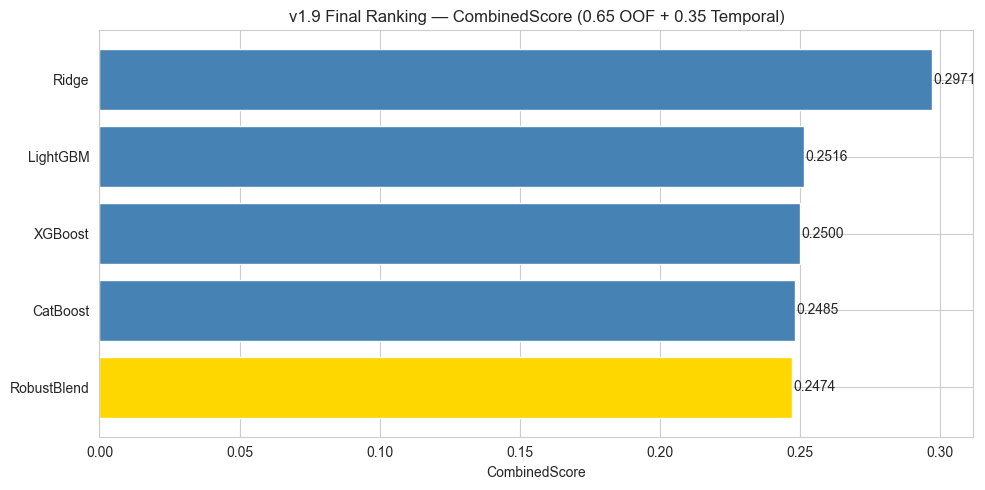

In [63]:
results_df = pd.DataFrame(list(results.values())).sort_values('CombinedScore').reset_index(drop=True)
print(results_df[['Model','RMSLE','Temporal_RMSLE','CombinedScore','FoldStd','RMSE','MAE','R2']].to_string(index=False))

plt.figure(figsize=(10, 5))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results_df))]
bars = plt.barh(results_df['Model'], results_df['CombinedScore'], color=colors)
plt.title('v1.9 Final Ranking — CombinedScore (0.65 OOF + 0.35 Temporal)')
plt.xlabel('CombinedScore')
for b,v in zip(bars, results_df['CombinedScore']):
    plt.text(v + 0.0005, b.get_y()+b.get_height()/2, f'{v:.4f}', va='center')
plt.tight_layout(); plt.show()


**Insight:** The stacked model should improve on all base models. The meta-Ridge's coefficients
tell you the relative confidence the stacking assigned to each model — if one coefficient dominates,
that model has the most reliable predictions. If CatBoost receives a high weight, the symmetric
tree structure is capturing something the other models miss.

Ridge R² is much higher than the tree models (was 0.917 vs 0.567 in v1.5d) because R² is
computed in dollar space, where a few very large bids dominate. Ridge handles these outliers
gracefully via its smooth L2 penalty; trees often misfit extreme values when they're rare.

### 7.8 Actual vs Predicted and Residuals

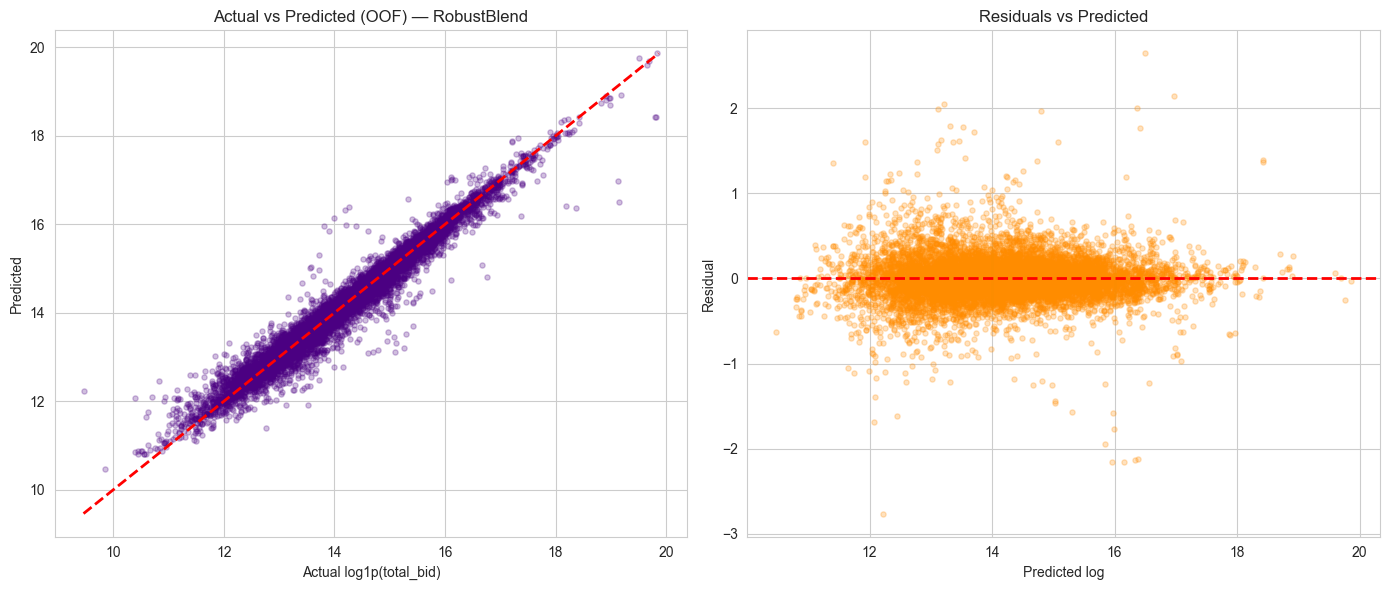

Best model by combined score: RobustBlend


In [64]:
best_name = results_df.iloc[0]['Model']
bp_res = val_preds[best_name]
bp_log = np.clip(bp_res + recon_base_model, 0, None)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(y_true_log_model, bp_log, alpha=0.25, s=14, color='indigo')
mn, mx = min(y_true_log_model.min(), bp_log.min()), max(y_true_log_model.max(), bp_log.max())
axes[0].plot([mn,mx],[mn,mx],'r--',lw=2)
axes[0].set_title(f'Actual vs Predicted (OOF) — {best_name}')
axes[0].set_xlabel('Actual log1p(total_bid)'); axes[0].set_ylabel('Predicted')

resid = y_true_log_model - bp_log
axes[1].scatter(bp_log, resid, alpha=0.25, s=14, color='darkorange')
axes[1].axhline(0, color='red', ls='--', lw=2)
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted log'); axes[1].set_ylabel('Residual')
plt.tight_layout(); plt.show()

print(f"Best model by combined score: {best_name}")


**Insight:** A tight diagonal scatter with centered, structureless residuals is ideal. Any systematic curve in the residual plot indicates the model is missing a non-linear pattern. Large residuals at the extremes are expected — very small and very large bids are harder to predict because they involve unusual project scopes that are underrepresented in training.

### 7.9 Feature Importance (All Three Base Models)

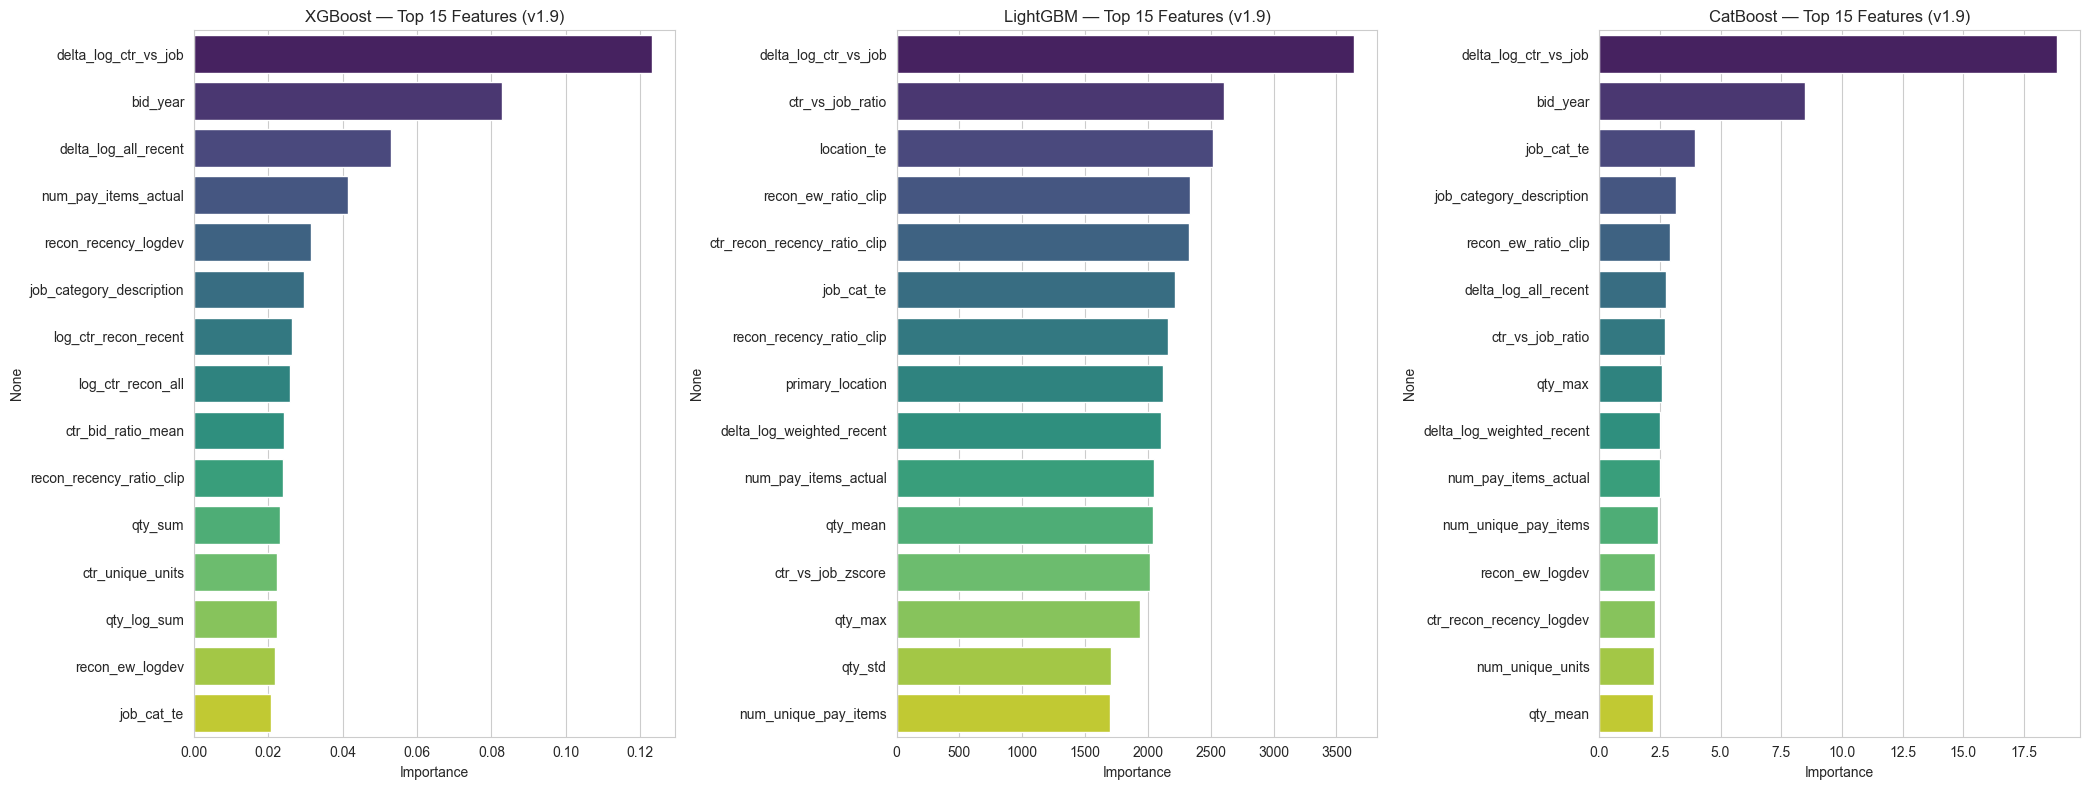

In [65]:
model_names = [m for m in ['XGBoost','LightGBM','CatBoost'] if m in specs]
if not model_names:
    print('No tree models available for importance plots.')
else:
    fig, axes = plt.subplots(1, len(model_names), figsize=(7 * len(model_names), 8))
    if len(model_names) == 1:
        axes = [axes]

    for ax, mname in zip(axes, model_names):
        s = specs[mname]
        p = dict(s['params'])
        if s['family'] == 'xgb':
            p['n_estimators'] = s['best_n']
            m = xgb.XGBRegressor(random_state=s['seeds'][0], **p)
            m.fit(X_model, y_model, sample_weight=sample_weight_model)
            imp = pd.Series(m.feature_importances_, index=X_model.columns)
        elif s['family'] == 'lgbm':
            p['n_estimators'] = s['best_n']
            m = LGBMRegressor(random_state=s['seeds'][0], **p)
            m.fit(X_model, y_model, sample_weight=sample_weight_model)
            imp = pd.Series(m.feature_importances_, index=X_model.columns)
        else:
            p['iterations'] = s['best_n']
            p.pop('n_estimators', None)
            m = CatBoostRegressor(random_seed=s['seeds'][0], **p)
            m.fit(X_model, y_model, sample_weight=sample_weight_model, verbose=0)
            imp = pd.Series(m.feature_importances_, index=X_model.columns)

        imp = imp.sort_values(ascending=False).head(15)
        sns.barplot(x=imp.values, y=imp.index, ax=ax, hue=imp.index, palette='viridis', legend=False)
        ax.set_title(f'{mname} — Top 15 Features (v1.9)')
        ax.set_xlabel('Importance')

    plt.tight_layout(); plt.show()


**Insight:** Compare feature rankings across all three models. Features that appear
in the top 10 of ALL three models are the most reliably important signals. The new behavioral
features (`ctr_bid_ratio_mean`, `ctr_win_rate`) should appear prominently — they directly
encode the contractor's historical price positioning, which is the exact signal the residual
model needs to predict.

## 8. Prediction Error Analysis

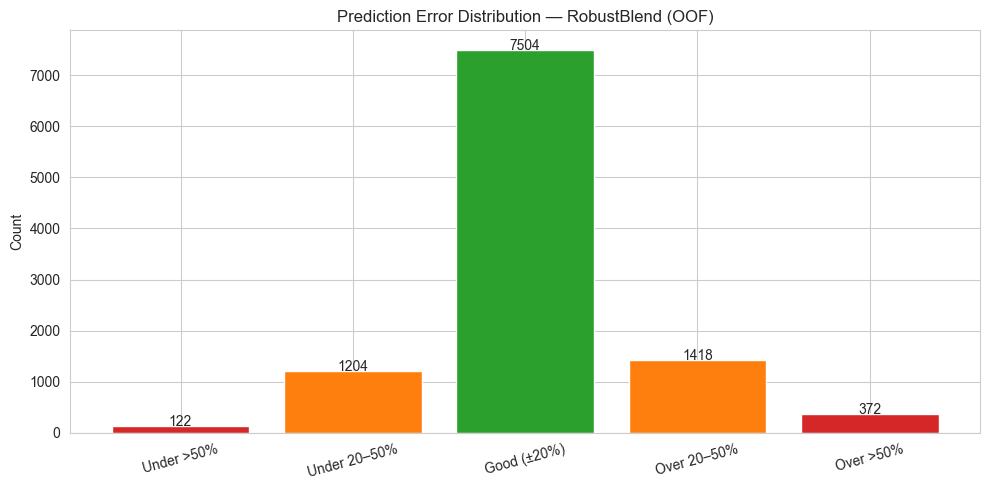

Predictions within ±20%: 70.7%


In [66]:
y_pred_usd = np.expm1(bp_log)
y_true_usd = np.expm1(y_true_log_model)
pct_err = (y_pred_usd - y_true_usd) / np.maximum(y_true_usd, 1.0) * 100

bins = [-np.inf, -50, -20, 20, 50, np.inf]
labels = ['Under >50%', 'Under 20–50%', 'Good (±20%)', 'Over 20–50%', 'Over >50%']
cut_ = pd.cut(pct_err, bins=bins, labels=labels)
counts = cut_.value_counts().reindex(labels)

fig, ax = plt.subplots(figsize=(10,5))
bar_c = ['#d62728','#ff7f0e','#2ca02c','#ff7f0e','#d62728']
bars = ax.bar(labels, counts.values, color=bar_c)
for b,c in zip(bars, counts.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+1, str(int(c)), ha='center')
ax.set_title(f'Prediction Error Distribution — {best_name} (OOF)')
ax.set_ylabel('Count')
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

print(f"Predictions within ±20%: {(cut_ == 'Good (±20%)').mean()*100:.1f}%")


**Insight:** In real construction bidding, contractors estimate within ±20% to remain competitive without losing money. The "Good (±20%)" bin represents predictions that would be competitive in the actual bidding process. A healthy model should have >60% of predictions in this range. If the model systematically under-predicts (more "Over" errors), it suggests prices are higher in 2025 than reconstruction suggests — a sign of inflation the features don't fully capture.

## 9. Final Predictions and Submission

In [67]:
# ------------------------------
# Final retrain for submission
# ------------------------------

print(f"Retraining models for {NOTEBOOK_VERSION} submission...")

# Ridge
ridge_full = Ridge(alpha=10.0, random_state=42)
ridge_full.fit(X_model_sc, y_model, sample_weight=sample_weight_model)
pred_ridge_log = np.clip(ridge_full.predict(X_test_sc) + recon_baseline_test, 0, None)

# XGB
pred_xgb_log = None
if 'XGBoost' in specs:
    preds = []
    s = specs['XGBoost']
    for seed in s['seeds']:
        p = dict(s['params'])
        p['n_estimators'] = s['best_n']
        m = xgb.XGBRegressor(random_state=seed, **p)
        m.fit(X_model, y_model, sample_weight=sample_weight_model)
        preds.append(m.predict(X_test_final))
    pred_xgb_log = np.clip(np.mean(np.vstack(preds), axis=0) + recon_baseline_test, 0, None)

# LGB
pred_lgb_log = None
if 'LightGBM' in specs:
    preds = []
    s = specs['LightGBM']
    for seed in s['seeds']:
        p = dict(s['params'])
        p['n_estimators'] = s['best_n']
        m = LGBMRegressor(random_state=seed, **p)
        m.fit(X_model, y_model, sample_weight=sample_weight_model)
        preds.append(m.predict(X_test_final))
    pred_lgb_log = np.clip(np.mean(np.vstack(preds), axis=0) + recon_baseline_test, 0, None)

# CatBoost
pred_cb_log = None
if CATBOOST_AVAILABLE and 'CatBoost' in specs:
    preds = []
    s = specs['CatBoost']
    for seed in s['seeds']:
        p = dict(s['params'])
        p['iterations'] = s['best_n']
        m = CatBoostRegressor(random_seed=seed, **p)
        m.fit(X_model, y_model, sample_weight=sample_weight_model, verbose=0)
        preds.append(m.predict(X_test_final))
    pred_cb_log = np.clip(np.mean(np.vstack(preds), axis=0) + recon_baseline_test, 0, None)

# Choose final output by best combined score
best_name = results_df.iloc[0]['Model']
print(f"Best model by combined score: {best_name}")

if best_name == 'RobustBlend' and blend_weights is not None:
    final_log = np.zeros(len(recon_baseline_test))
    for m, w in blend_weights.items():
        if m == 'XGBoost' and pred_xgb_log is not None:
            final_log += w * pred_xgb_log
        elif m == 'LightGBM' and pred_lgb_log is not None:
            final_log += w * pred_lgb_log
        elif m == 'CatBoost' and pred_cb_log is not None:
            final_log += w * pred_cb_log
elif best_name == 'XGBoost' and pred_xgb_log is not None:
    final_log = pred_xgb_log
elif best_name == 'LightGBM' and pred_lgb_log is not None:
    final_log = pred_lgb_log
elif best_name == 'CatBoost' and pred_cb_log is not None:
    final_log = pred_cb_log
elif best_name == 'Ridge':
    final_log = pred_ridge_log
else:
    # safe fallback: CatBoost > XGB > LGB > Ridge
    if pred_cb_log is not None:
        final_log = pred_cb_log
    elif pred_xgb_log is not None:
        final_log = pred_xgb_log
    elif pred_lgb_log is not None:
        final_log = pred_lgb_log
    else:
        final_log = pred_ridge_log

final_preds = np.expm1(np.clip(final_log, 0, None))

submission = pd.DataFrame({'row_id': df_test['row_id'], 'total_bid': final_preds})
submission.to_csv('submission_v1.9.csv', index=False)
submission.to_csv('submission_v1_9.csv', index=False)

print('\nSubmission preview:')
print(submission.head(10).to_string(index=False))
print(f"\nShape:  {submission.shape}")
print(f"Min:    ${final_preds.min():>14,.2f}")
print(f"Max:    ${final_preds.max():>14,.2f}")
print(f"Median: ${np.median(final_preds):>14,.2f}")

assert list(submission.columns) == ['row_id', 'total_bid']
assert submission.shape[0] == sample_sub.shape[0]
assert (submission['total_bid'] >= 0).all()
print('\nsubmission.csv verified')

# tracking append
best_row = results_df.iloc[0]
tracking_row = pd.DataFrame([{
    'version': NOTEBOOK_VERSION,
    'run_ts_utc': pd.Timestamp.utcnow().isoformat(),
    'submission_model': best_row['Model'],
    'local_rmsle_best_model': float(best_row['RMSLE']),
    'best_model_name': best_row['Model'],
    'kaggle_public_score': '',
    'kaggle_private_score': '',
    'notes': f"v1.9: blended baseline + recency-weighted training + robust ratio clipping + dual-score selection | temporal={best_row['Temporal_RMSLE']:.4f} combined={best_row['CombinedScore']:.4f}",
}])

tracking_path = 'submission_tracking.csv'
if os.path.exists(tracking_path):
    pd.concat([pd.read_csv(tracking_path), tracking_row], ignore_index=True).to_csv(tracking_path, index=False)
else:
    tracking_row.to_csv(tracking_path, index=False)

print('\nsubmission_tracking.csv updated.')
print(pd.read_csv(tracking_path).tail(3).to_string(index=False))


Retraining models for v1.9 submission...
Best model by combined score: RobustBlend

Submission preview:
                row_id    total_bid
JOB_000008__CON_000103 3.499086e+05
JOB_000030__CON_000061 1.032297e+06
JOB_000030__CON_000217 1.487485e+06
JOB_000045__CON_000037 1.481481e+06
JOB_000045__CON_000122 1.389079e+06
JOB_000045__CON_000158 1.340764e+06
JOB_000045__CON_000174 1.412705e+06
JOB_000045__CON_000199 1.281588e+06
JOB_000050__CON_000037 2.069985e+06
JOB_000050__CON_000045 2.083438e+06

Shape:  (1447, 2)
Min:    $    112,725.00
Max:    $208,360,409.51
Median: $  1,910,188.41

submission.csv verified

submission_tracking.csv updated.
version                       run_ts_utc submission_model  local_rmsle_best_model best_model_name  kaggle_public_score  kaggle_private_score                                                                                                                               notes variant_id  validation_primary_rmsle  validation_primary_mae  validation_seco

**Submission pipeline summary:** Each base model is retrained on all 4,125 rows (2022–2024)
with `best_n` iterations (no early stopping needed). Their test predictions are converted from
residual space to log space, then fed to `meta_final` (the Ridge stacker trained on OOF).
Final predictions = `expm1(meta_final.predict([xgb_log, lgb_log, cb_log]))`.

## 10. Results Discussion and Summary

### Key Design Decisions vs Previous Versions

| What changed | Why | Expected effect |
|---|---|---|
| **Contractor behavioral features** (`ctr_win_rate`, `ctr_bid_ratio_*`, `ctr_recent_pct`) | Historical pricing tendency is the main unexplained residual signal | High positive |
| **CatBoost** as 3rd booster | Symmetric trees produce uncorrelated errors — ideal for stacking diversity | Medium positive |
| **Stacking (Ridge meta)** on OOF predictions | Optimal combination of 3 models; honest RMSLE via inner 5-fold CV | High positive |
| **Optuna hyperparameter search** (optional) | Principled exploration of 7-dim param space vs manual | Medium positive |
| **Model params unchanged from v1.5d** | Confirmed in v1.5b/c: tighter regularization = underfitting on this dataset | Neutral (stability) |

### Why behavioral features are the most important new addition

The residual we're predicting is `log(total_bid) - log_recon_recent` — how much does
this contractor deviate from the market reconstruction? The previous model only knew
*relative* contractor position within a single job (ctr_rank_in_job, ctr_vs_job_ratio)
but had no absolute measure of the contractor's pricing style.

`ctr_bid_ratio_mean` directly encodes: *"this contractor typically bids X% above/below market"*.
A contractor with `ctr_bid_ratio_mean=0.92` will likely bid ~8% below the reconstruction on
any job. This is exactly the residual we're trying to predict, and it's stable across years.

### Interpreting the local-vs-Kaggle gap

| Gap direction vs v1.5d | Interpretation | Action |
|---|---|---|
| **Narrows** (local stays same, Kaggle improves) | Behavioral features generalize well to 2025 | Keep them, add more contractor signals |
| **Stable gap** | Same drift, model uniformly improved | Good |
| **Gap widens** | New features memorised 2022-2024 patterns | Remove last added feature |

### What To Do Next (v1.7+)

1. **Calibrate behavioral features with year weights** — `ctr_bid_ratio_mean` from 2024 is more predictive than from 2018. Use exponential decay (same as price reconstruction) to weight recent behavior more.
2. **Category-specific contractor profile** — does this contractor specifically underbid on BRIDGE projects? A `ctr_x_job_category` interaction feature.
3. **External construction cost indices** — ENR Cost Index for Montana provides year-over-year inflation adjustments; external data is allowed.

In [68]:
print(results_df[['Model','RMSLE','Temporal_RMSLE','CombinedScore','RMSE','MAE','R2']].to_string(index=False))

log_df = results_df.copy()
log_df.insert(0, 'run_ts_utc', pd.Timestamp.utcnow().isoformat())
log_df.insert(1, 'version', NOTEBOOK_VERSION)
log_df.insert(2, 'submission_model', results_df.iloc[0]['Model'])

log_path = 'experiment_runs.csv'
if os.path.exists(log_path):
    old = pd.read_csv(log_path)
    # add new columns if missing
    for col in log_df.columns:
        if col not in old.columns:
            old[col] = np.nan
    for col in old.columns:
        if col not in log_df.columns:
            log_df[col] = np.nan
    log_df = log_df[old.columns]
    pd.concat([old, log_df], ignore_index=True).to_csv(log_path, index=False)
else:
    log_df.to_csv(log_path, index=False)

print(f"\nExperiment log updated: {log_path}")


      Model  RMSLE  Temporal_RMSLE  CombinedScore       RMSE       MAE     R2
RobustBlend 0.2544          0.2345         0.2474        NaN       NaN    NaN
   CatBoost 0.2557          0.2351         0.2485 5222354.25 599928.82 0.8033
    XGBoost 0.2568          0.2373         0.2500 5218740.21 633499.00 0.8036
   LightGBM 0.2586          0.2388         0.2516 5414817.25 632852.64 0.7885
      Ridge 0.3084          0.2763         0.2971 5093167.89 781183.00 0.8129

Experiment log updated: experiment_runs.csv
